# Задача на табличных данных

В данной работе @Данил Растяпин и @Глеб Плаксин будут делать задачу, основанную на табличных данных


Поставленная задача: __предсказывать риск аварии с пострадавшими на основе табличных признаков.__

Было решено взять датасет: [Cincinnati Car Crash Data](https://www.kaggle.com/datasets/steverusso/cincinnati-car-crash-data)

В качестве бизнес-заказчика можно рассматривать страховую компанию, которая занимается автострахованием и страхованием жизни. Компании важно заранее оценивать, какие ДТП с большей вероятностью приводят к травмам или смерти, так как именно такие случаи связаны с более высокими страховыми выплатами.

Мы хотим предсказывать вероятность того, что авария приведет к пострадавшим.

Соответственно, наша задача — бинарная классификация:

- `0` — авария без пострадавших, только материальный ущерб;
- `1` — авария с пострадавшими или летальным исходом.

Для решения задачи мы будем использовать полносвязную нейронную сеть, так как данные представлены в табличном виде: каждая авария описывается набором признаков, таких как погода, освещение, тип дороги, район, тип столкновения и характеристики участников.

## Обоснование корректности применения полносвязной нейронной сети
Небольшой дисклеймер: для решения задачи на табличных данных вполне корректно использовать полносвязную нейронную сеть, так как данные представлены в виде набора признаков, описывающих каждый объект наблюдения.

Например, x = [признак1, признак2, итд...]

Ее главное преимущество в сравнении с базовыми линейными моделями заключается в способности автоматически находить сложные нелинейные зависимости в данных, избавляя от необходимости вручную конструировать признаки. Это же __круто__!!! При всем при этом это также очень важно.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import os
import time
import joblib

папочки для логов

In [341]:
os.makedirs("artifacts/models", exist_ok=True)
os.makedirs("artifacts/preprocessors", exist_ok=True)
os.makedirs("artifacts/plots", exist_ok=True)
os.makedirs("artifacts/data", exist_ok=True)
os.makedirs("artifacts/data/EntityEmbeddingNet", exist_ok=True)

In [ ]:
df = pd.read_csv("cincinnati_traffic_crash_data__cpd.csv").drop(columns = 'Unnamed: 0')
df.head()

/tmp/ipykernel_2181/3656284645.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cincinnati_traffic_crash_data__cpd.csv").drop(columns = 'Unnamed: 0')


,ADDRESS_X,LATITUDE_X,LONGITUDE_X,AGE,COMMUNITY_COUNCIL_NEIGHBORHOOD,CPD_NEIGHBORHOOD,CRASHDATE,CRASHLOCATION,CRASHSEVERITY,CRASHSEVERITYID,...,LOCALREPORTNO,MANNEROFCRASH,ROADCONDITIONSPRIMARY,ROADCONTOUR,ROADSURFACE,SNA_NEIGHBORHOOD,TYPEOFPERSON,WEATHER,ZIP,UNITTYPE
0,63XX GRACELY,39.107808,-84.688195,31-40,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,...,145004877,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,45233.0,03 - MID SIZE
1,9XX CHATEAU AV,39.108110,-84.560280,18-25,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,...,155002081,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,45204.0,02 - COMPACT
2,30XX READING RD,39.135486,-84.496520,18-25,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,...,155010090,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,45206.0,04 - FULL SIZE
3,36XX READING RD,39.147889,-84.489222,61-70,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,...,185005525,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,45229.0,07 - PICKUP
4,37XX WARSAW AV,39.110989,-84.573138,31-40,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,...,185012267,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,45205.0,04 - FULL SIZE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258672 entries, 0 to 258671
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ADDRESS_X                       258669 non-null  object 
 1   LATITUDE_X                      258672 non-null  float64
 2   LONGITUDE_X                     258672 non-null  float64
 3   AGE                             258672 non-null  object 
 4   COMMUNITY_COUNCIL_NEIGHBORHOOD  253006 non-null  object 
 5   CPD_NEIGHBORHOOD                252959 non-null  object 
 6   CRASHDATE                       258669 non-null  object 
 7   CRASHLOCATION                   194021 non-null  object 
 8   CRASHSEVERITY                   258672 non-null  object 
 9   CRASHSEVERITYID                 258672 non-null  float64
 10  DATECRASHREPORTED               258670 non-null  object 
 11  DAYOFWEEK                       258671 non-null  object 
 12  GENDER          

## Интерпретация полученных признаков
| №  | Признак                                      | Тип признака       | Что это |
|----|----------------------------------------------|--------------------|--------|
| 1  | Address_X         | Текстовый      | Адрес с маскированным домом |
| 2  | COMMUNITY_COUNCIL_NEIGHBORHOOD             | Категориальный      | Район |
| 3  | CPD_NEIGHBORHOOD         | Категориальный      | Ближайшее отделение полиции |
| 4  | CPD_NEIGHBORHOOD             | Категориальный      | Тип дороги, где произошла авария |
| 5  | CRASHSEVERITY                            | Категориальный    | Летальность аварии (сразу всмятку или лайтово) |
| 6  | INSTANCEID                                      | Числовой        | ID аварии|
| 7  | LIGHTCONDITIONSPRIMARY                      | Категориальный         | Небо во время аварии |
| 8  |  MANNEROFCRASH                           | Категориальный         |  Тип аварии |
| 9 | TYPEOFPERSON                                    | Категориальный     | Кто попал в аварию (пассажир, пешеход, водитель) |
| 10 |  UNITTYPE                             | Категориальный        | Какой вид автомобиля |

In [ ]:
df.CRASHSEVERITY.unique()

array(['3 - PROPERTY DAMAGE ONLY (PDO)', '2 - INJURY', '1 - FATAL INJURY',
       '5 - PROPERTY DAMAGE ONLY', '4 - INJURY POSSIBLE',
       '3 - MINOR INJURY SUSPECTED', '2 - SERIOUS INJURY SUSPECTED',
       '1 - FATAL'], dtype=object)

In [ ]:
df.INJURIES.unique()

array(['1 - NO INJURY / NONE REPORTED', '3 - NON-INCAPACITATING',
       '5 - NO APPARENTY INJURY', '4 - POSSIBLE INJURY',
       '3 - SUSPECTED MINOR INJURY', '2 - POSSIBLE', '4 - INCAPACITATING',
       '2 - SUSPECTED SERIOUS INJURY', '5 - FATAL', nan, '1 - FATAL'],
      dtype=object)

In [ ]:
temp = df[['INJURIES', 'CRASHSEVERITY','ADDRESS_X']].groupby(['CRASHSEVERITY','INJURIES']).count()
temp

ADDRESS_X
CRASHSEVERITY                  INJURIES                                
1 - FATAL                      1 - FATAL                             66
                               1 - NO INJURY / NONE REPORTED          3
                               2 - SUSPECTED SERIOUS INJURY          26
                               3 - SUSPECTED MINOR INJURY            32
                               4 - POSSIBLE INJURY                   13
                               5 - FATAL                              2
                               5 - NO APPARENTY INJURY               45
1 - FATAL INJURY               1 - NO INJURY / NONE REPORTED        110
                               2 - POSSIBLE                          13
                               3 - NON-INCAPACITATING                42
                               4 - INCAPACITATING                    52
                               5 - FATAL                            172
2 - INJURY                     1 - NO INJURY / NONE REPORTED      21196
                               2 - POSSIBLE                       15297
                               3 - NON-INCAPACITATING             10317
                               4 - INCAPACITATING                  2007
                               4 - POSSIBLE INJURY                    4
                               5 - NO APPARENTY INJURY                2
2 - SERIOUS INJURY SUSPECTED   1 - NO INJURY / NONE REPORTED          8
                               2 - POSSIBLE                           5
                               2 - SUSPECTED SERIOUS INJURY         486
                               3 - NON-INCAPACITATING                 4
                               3 - SUSPECTED MINOR INJURY           154
                               4 - INCAPACITATING                     8
                               4 - POSSIBLE INJURY                   56
                               5 - NO APPARENTY INJURY              303
3 - MINOR INJURY SUSPECTED     1 - NO INJURY / NONE REPORTED          9
                               2 - SUSPECTED SERIOUS INJURY           1
                               3 - NON-INCAPACITATING                 8
                               3 - SUSPECTED MINOR INJURY          4954
                               4 - POSSIBLE INJURY                  653
                               5 - NO APPARENTY INJURY             3713
3 - PROPERTY DAMAGE ONLY (PDO) 1 - NO INJURY / NONE REPORTED     144522
                               2 - POSSIBLE                           1
                               5 - NO APPARENTY INJURY               16
4 - INJURY POSSIBLE            1 - NO INJURY / NONE REPORTED          2
                               2 - POSSIBLE                           3
                               4 - POSSIBLE INJURY                 4201
                               5 - NO APPARENTY INJURY             3584
5 - PROPERTY DAMAGE ONLY       1 - NO INJURY / NONE REPORTED         64
                               4 - POSSIBLE INJURY                    1
                               5 - NO APPARENTY INJURY            46293

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
temp = df[['crashseverity', 'crashseverityid']].groupby(['crashseverity','crashseverityid']).count()
temp

,
crashseverity,crashseverityid
1 - FATAL,201901.0
1 - FATAL INJURY,1.0
2 - INJURY,2.0
2 - SERIOUS INJURY SUSPECTED,201902.0
3 - MINOR INJURY SUSPECTED,201903.0
3 - PROPERTY DAMAGE ONLY (PDO),3.0
4 - INJURY POSSIBLE,201904.0
5 - PROPERTY DAMAGE ONLY,201905.0


Наверное, в какой-то момент изменилось, то, как кодируют степень тяжести нанесенного ущерба. Или для разных городов разные коды

In [ ]:
df.drop(columns = ['zip', 'address_x',], inplace = True)

In [ ]:
df

,latitude_x,longitude_x,age,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,datecrashreported,...,lightconditionsprimary,localreportno,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,typeofperson,weather,unittype
0,39.107808,-84.688195,31-40,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,06/17/2014 05:29:00 PM,...,1 - DAYLIGHT,145004877,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,03 - MID SIZE
1,39.108110,-84.560280,18-25,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,02/15/2015 03:10:00 PM,...,1 - DAYLIGHT,155002081,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,02 - COMPACT
2,39.135486,-84.496520,18-25,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,07/23/2015 11:54:00 PM,...,4 - DARK - LIGHTED ROADWAY,155010090,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,04 - FULL SIZE
3,39.147889,-84.489222,61-70,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/21/2018 01:16:00 PM,...,1 - DAYLIGHT,185005525,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,07 - PICKUP
4,39.110989,-84.573138,31-40,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,09/01/2018 07:59:00 PM,...,3 - DUSK,185012267,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,04 - FULL SIZE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258667,39.159659,-84.402688,61-70,MADISONVILLE,MADISONVILLE,04/17/2018 04:46:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/17/2018 04:51:00 PM,...,1 - DAYLIGHT,185005351,2 - REAR-END,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",MADISONVILLE,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE
258668,39.140463,-84.602730,18-25,WESTWOOD,WESTWOOD,11/06/2014 10:21:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,11/06/2014 10:22:00 PM,...,4 - DARK - LIGHTED ROADWAY,145011351,6 - ANGLE,02 - WET,1 - STRAIGHT LEVEL,1 - CONCRETE,WESTWOOD,D - DRIVER,1 - CLEAR,03 - MID SIZE
258669,39.113840,-84.592351,51-60,WEST PRICE HILL,WEST PRICE HILL,01/28/2015 02:41:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2015 02:41:00 PM,...,1 - DAYLIGHT,155001202,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WEST PRICE HILL,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE
258670,39.136956,-84.605497,26-30,WESTWOOD,WESTWOOD,05/31/2014 12:20:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,05/31/2014 12:26:00 PM,...,1 - DAYLIGHT,145004142,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WESTWOOD,D - DRIVER,1 - CLEAR,04 - FULL SIZE


### Несколько пассажиров

Также в ходе анализа было выявленно, что localreportno иногда повторяются.

In [ ]:
df[df['localreportno'] == 145001250]

,latitude_x,longitude_x,age,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,datecrashreported,...,lightconditionsprimary,localreportno,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,typeofperson,weather,unittype
110049,39.098891,-84.533526,51-60,QUEENSGATE,QUEENSGATE,02/13/2014 01:10:00 PM,08 - OFF RAMP,2 - INJURY,2.0,02/13/2014 01:12:00 PM,...,1 - DAYLIGHT,145001250,2 - REAR-END,02 - WET,4 - CURVE GRADE,1 - CONCRETE,QUEENSGATE,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE
184132,39.099991,-84.534216,51-60,QUEENSGATE,QUEENSGATE,02/13/2014 01:10:00 PM,08 - OFF RAMP,2 - INJURY,2.0,02/13/2014 01:12:00 PM,...,1 - DAYLIGHT,145001250,2 - REAR-END,02 - WET,4 - CURVE GRADE,1 - CONCRETE,QUEENSGATE,O - OCCUPANT,1 - CLEAR,06 - SPORT UTILITY VEHICLE
200745,39.100121,-84.533446,18-25,QUEENSGATE,QUEENSGATE,02/13/2014 01:10:00 PM,08 - OFF RAMP,2 - INJURY,2.0,02/13/2014 01:12:00 PM,...,1 - DAYLIGHT,145001250,2 - REAR-END,02 - WET,4 - CURVE GRADE,1 - CONCRETE,QUEENSGATE,D - DRIVER,1 - CLEAR,03 - MID SIZE


Например, здесь мы видим что в одной аварии участвовало три человека ———— две женщины 51-60 и мужчина 18-25, причем одна женщина и мужчина отмечены оба как "DRIVER" и они оба без травм, а вот у второй пассажирки травма "NON-INCAPACITATING", мешающая повседневной жизни.

### Агреггируем строки аварии

Так как один localreportno может появляться несколько раз, мы можем понять, что одна строка датасета — это один из участников аварии(>=1)

Для бизнес-задачи нам нужно предсказывать тяжесть аварии целиком, поэтому дальше агрегируем данные до уровня одной аварии.

Взглянем на то, сколько строк может приходиться на одну аварию

In [ ]:
df.groupby('localreportno').size().sort_values(ascending=False)

,0
localreportno,
135001864,43
185005626,33
175003760,27
175003358,26
195018224,21
...,...
185016603,1
185016599,1
185016597,1


In [ ]:
df[df['localreportno'] == 135001864]

,latitude_x,longitude_x,age,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,datecrashreported,...,lightconditionsprimary,localreportno,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,typeofperson,weather,unittype
2927,39.180801,-84.519626,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
5651,39.182311,-84.520696,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
11093,39.180991,-84.519686,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
19320,39.181191,-84.519716,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
21218,39.181251,-84.519876,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
24425,39.181701,-84.520576,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
28016,39.181751,-84.520926,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
28080,39.181211,-84.520096,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
31243,39.181371,-84.521216,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"
34505,39.180901,-84.521086,UNDER 18,SPRING GROVE - WINTON HILLS,WINTON HILLS,01/28/2013 02:30:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2013 02:33:00 PM,...,1 - DAYLIGHT,135001864,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WINTON HILLS,O - OCCUPANT,2 - CLOUDY,"22 - BUS (16+ SEATS, INCLUDING THE DRIVER)"


На этом примере мы видим огромный автобус с детишками на 43 человек. Вело автобус два водителя. Взглянем на распределение

In [ ]:
import plotly.express as px

In [ ]:
reports_count = df.groupby('localreportno').size().reset_index(name='rows_per_accident')
px.histogram(reports_count, x='rows_per_accident', title='строк на одну аварию')

Смертельных аварий очень мало, модель может плоховато обучиться на редком классе. Поэтому берем за таргет наличие пострадавших.

In [ ]:
df['target'] = (~df['crashseverity'].str.contains('PROPERTY DAMAGE ONLY', case=False, na=False)).astype(int)
df

,latitude_x,longitude_x,age,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,datecrashreported,...,localreportno,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,typeofperson,weather,unittype,target
0,39.107808,-84.688195,31-40,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,06/17/2014 05:29:00 PM,...,145004877,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,03 - MID SIZE,0
1,39.108110,-84.560280,18-25,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,02/15/2015 03:10:00 PM,...,155002081,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,02 - COMPACT,1
2,39.135486,-84.496520,18-25,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,07/23/2015 11:54:00 PM,...,155010090,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,04 - FULL SIZE,0
3,39.147889,-84.489222,61-70,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/21/2018 01:16:00 PM,...,185005525,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,07 - PICKUP,0
4,39.110989,-84.573138,31-40,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,09/01/2018 07:59:00 PM,...,185012267,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,04 - FULL SIZE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258667,39.159659,-84.402688,61-70,MADISONVILLE,MADISONVILLE,04/17/2018 04:46:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/17/2018 04:51:00 PM,...,185005351,2 - REAR-END,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",MADISONVILLE,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE,0
258668,39.140463,-84.602730,18-25,WESTWOOD,WESTWOOD,11/06/2014 10:21:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,11/06/2014 10:22:00 PM,...,145011351,6 - ANGLE,02 - WET,1 - STRAIGHT LEVEL,1 - CONCRETE,WESTWOOD,D - DRIVER,1 - CLEAR,03 - MID SIZE,0
258669,39.113840,-84.592351,51-60,WEST PRICE HILL,WEST PRICE HILL,01/28/2015 02:41:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2015 02:41:00 PM,...,155001202,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WEST PRICE HILL,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE,0
258670,39.136956,-84.605497,26-30,WESTWOOD,WESTWOOD,05/31/2014 12:20:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,05/31/2014 12:26:00 PM,...,145004142,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WESTWOOD,D - DRIVER,1 - CLEAR,04 - FULL SIZE,0


In [ ]:
df['target'].value_counts()

,count
target,
0,191120
1,67552


Прекрасно! __67__,552 строчек аварий с травмами. И 191,120 строчек аварий без травм (только проперти дэмэдж).

Теперь аггрегируем участников аварий, чтобы мы могли детально знать кол-во пострадавших и прочие показатели


### Агрегируем количество участников
Посчитаем, сколько участников на каждую аварию

In [ ]:
num_people = df.groupby('localreportno').size().reset_index(name='num_people')
num_people

,localreportno,num_people
0,14,2
1,15,1
2,30,2
3,31,3
4,1455001,1
...,...,...
133868,215000458,1
133869,215000459,1
133870,215000460,1
133871,215000461,2


In [ ]:
num_people['num_people'].describe()

,num_people
count,133873.000000
mean,1.932219
std,0.845384
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,43.000000


Посчитаем количество водителей, пассажиров и пешеходов на каждую аварию

In [ ]:
num_drivers = (df.groupby('localreportno')['typeofperson'].apply(lambda x: (x == 'D - DRIVER').sum()).reset_index(name='num_drivers'))
num_drivers

,localreportno,num_drivers
0,14,2
1,15,1
2,30,2
3,31,3
4,1455001,1
...,...,...
133868,215000458,1
133869,215000459,1
133870,215000460,1
133871,215000461,2


In [ ]:
num_occupants = (df.groupby('localreportno')['typeofperson'].apply(lambda x: (x == 'O - OCCUPANT').sum()).reset_index(name='num_occupants'))
num_occupants

,localreportno,num_occupants
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0
...,...,...
133868,215000458,0
133869,215000459,0
133870,215000460,0
133871,215000461,0


Был ли в аварии пешеход и сколько

In [ ]:
num_pedestrians = (df.groupby('localreportno')['typeofperson'].apply(lambda x: (x == 'P - PEDESTRIAN').sum()).reset_index(name='num_pedestrians'))
num_pedestrians

,localreportno,num_pedestrians
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0
...,...,...
133868,215000458,0
133869,215000459,0
133870,215000460,0
133871,215000461,0


In [ ]:
has_pedestrian = (df.groupby('localreportno')['typeofperson'].apply(lambda x: int((x == 'P - PEDESTRIAN').any())).reset_index(name='has_pedestrian'))
has_pedestrian

,localreportno,has_pedestrian
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0
...,...,...
133868,215000458,0
133869,215000459,0
133870,215000460,0
133871,215000461,0


In [ ]:
has_occupant = (df.groupby('localreportno')['typeofperson'].apply(lambda x: int((x == 'O - OCCUPANT').any())).reset_index(name='has_occupant'))
has_occupant

,localreportno,has_occupant
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0
...,...,...
133868,215000458,0
133869,215000459,0
133870,215000460,0
133871,215000461,0


Теперь отдельно вщглянем на типы транспортных средств. Для страховой нужно понимать, участвовали ли в аварии мотоциклы, велосипеды, автобусы.

In [ ]:
has_bus = (df.groupby('localreportno')['unittype'].apply(lambda x: int(x.astype(str).str.contains('BUS', case=False, na=False).any())).reset_index(name='has_bus'))
has_bus

,localreportno,has_bus
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0
...,...,...
133868,215000458,0
133869,215000459,0
133870,215000460,0
133871,215000461,0


In [ ]:
has_motorcycle = (df.groupby('localreportno')['unittype'].apply(lambda x: int(x.astype(str).str.contains('MOTORCYCLE', case=False, na=False).any())).reset_index(name='has_motorcycle'))
has_motorcycle.head()

,localreportno,has_motorcycle
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0


In [ ]:
has_bicycle = (df.groupby('localreportno')['unittype'].apply(lambda x: int(x.astype(str).str.contains('BICYCLE', case=False, na=False).any())).reset_index(name='has_bicycle'))
has_bicycle.head()

,localreportno,has_bicycle
0,14,0
1,15,0
2,30,0
3,31,0
4,1455001,0


### Собираем признаки участников ДТП в одну витрину

In [ ]:
person_features = num_people.merge(num_drivers, on='localreportno', how='left')
person_features = person_features.merge(num_occupants, on='localreportno', how='left')
person_features = person_features.merge(num_pedestrians, on='localreportno', how='left')
person_features = person_features.merge(has_pedestrian, on='localreportno', how='left')
person_features = person_features.merge(has_occupant, on='localreportno', how='left')
person_features = person_features.merge(has_bus, on='localreportno', how='left')
person_features = person_features.merge(has_motorcycle, on='localreportno', how='left')
person_features = person_features.merge(has_bicycle, on='localreportno', how='left')

In [ ]:
person_features

,localreportno,num_people,num_drivers,num_occupants,num_pedestrians,has_pedestrian,has_occupant,has_bus,has_motorcycle,has_bicycle
0,14,2,2,0,0,0,0,0,0,0
1,15,1,1,0,0,0,0,0,0,0
2,30,2,2,0,0,0,0,0,0,0
3,31,3,3,0,0,0,0,0,0,0
4,1455001,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
133868,215000458,1,1,0,0,0,0,0,0,0
133869,215000459,1,1,0,0,0,0,0,0,0
133870,215000460,1,1,0,0,0,0,0,0,0
133871,215000461,2,2,0,0,0,0,0,0,0


__лол. в 675 авариях не было водителя. интересно__

Некоторые признаки одинаковые для всех строк внутри одного `localreportno`: погода, освещение, тип столкновения, дата, район и т.д. Их можно взять по одному разу.

In [ ]:
crash_cols = [
    'localreportno',
    'latitude_x',
    'longitude_x',
    'community_council_neighborhood',
    'cpd_neighborhood',
    'crashdate',
    'crashlocation',
    'crashseverity',
    'crashseverityid',
    'dayofweek',
    'lightconditionsprimary',
    'mannerofcrash',
    'roadconditionsprimary',
    'roadcontour',
    'roadsurface',
    'sna_neighborhood',
    'weather',
    'target'
]

In [ ]:
bad_coords = (~df['latitude_x'].between(38, 41) | ~df['longitude_x'].between(-86, -83))
bad_coords.sum()

np.int64(202)

аж 202 значения. не круто

так как таких строк мало, заменим некорректные координаты на пропуски.

In [ ]:
df.loc[bad_coords, ['latitude_x', 'longitude_x']] = np.nan
df[['latitude_x', 'longitude_x']].describe()

,latitude_x,longitude_x
count,258470.000000,258470.000000
mean,39.140806,-84.515360
std,0.033307,0.053150
min,39.023221,-85.514230
25%,39.116956,-84.548848
50%,39.136391,-84.514783
75%,39.160825,-84.484805
max,40.000081,-84.103780


In [ ]:
df_crash = df[crash_cols].drop_duplicates('localreportno')
df_crash.head()

,localreportno,latitude_x,longitude_x,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,dayofweek,lightconditionsprimary,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,weather,target
0,145004877,39.107808,-84.688195,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,1 - DAYLIGHT,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,1 - CLEAR,0
1,155002081,39.108110,-84.560280,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,SUN,1 - DAYLIGHT,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,1 - CLEAR,1
2,155010090,39.135486,-84.496520,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,THU,4 - DARK - LIGHTED ROADWAY,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,1 - CLEAR,0
3,185005525,39.147889,-84.489222,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,1 - DAYLIGHT,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,1 - CLEAR,0
4,185012267,39.110989,-84.573138,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,3 - DUSK,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,1 - CLEAR,0


Теперь соединим признаки самой аварии с агрегированными признаками участников.

In [ ]:
df_model = df_crash.merge(person_features, on='localreportno', how='left')
df_model

,localreportno,latitude_x,longitude_x,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,dayofweek,...,target,num_people,num_drivers,num_occupants,num_pedestrians,has_pedestrian,has_occupant,has_bus,has_motorcycle,has_bicycle
0,145004877,39.107808,-84.688195,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,0,2,2,0,0,0,0,0,0,0
1,155002081,39.108110,-84.560280,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,SUN,...,1,2,1,1,0,0,1,0,0,0
2,155010090,39.135486,-84.496520,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,THU,...,0,5,2,3,0,0,1,0,0,0
3,185005525,39.147889,-84.489222,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,2,2,0,0,0,0,0,0,0
4,185012267,39.110989,-84.573138,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,2,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133868,155016727,39.095846,-84.560807,SEDAMSVILLE,SEDAMSVILLE,11/17/2015 09:55:00 AM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,0,1,1,0,0,0,0,0,0,0
133869,155016340,39.099411,-84.502986,DOWNTOWN,C. B. D. / RIVERFRONT,11/09/2015 11:39:00 AM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,MON,...,0,1,1,0,0,0,0,0,0,0
133870,145004288,39.136355,-84.531823,CUF,CLIFTON/UNIVERSITY HEIGHTS,06/04/2014 07:03:00 AM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,WED,...,0,1,1,0,0,0,0,0,0,0
133871,195003855,39.138113,-84.531107,CUF,CLIFTON/UNIVERSITY HEIGHTS,03/24/2019 11:58:00 PM,NaN,5 - PROPERTY DAMAGE ONLY,201905.0,SUN,...,0,1,1,0,0,0,0,0,0,0


Теперь `df_model` — это уже финальная таблица для дальнейшего анализа и модели: одна строка соответствует одной аварии.

---

In [ ]:
px.histogram(df_model, x='target', title='распределение аварий без постральных и с пострадавшими')


### Пощупаем гипотезы и поищем эвристики

In [ ]:
df_model.groupby('has_pedestrian')['target'].mean()

,target
has_pedestrian,
0,0.192340
1,0.947523


<mark>То есть если в дтп участвовал пешеход, то почти в 95% случаев это дтп не относится к категории "property damage only". Лучше сидеть дома и никуда не выходить(</mark>

In [ ]:
df_model.groupby('mannerofcrash')['target'].agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
mannerofcrash,,
3 - HEAD-ON,2316,0.487910
1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES IN TRANSPORT,30023,0.265896
6 - ANGLE,34585,0.259824
2 - REAR-END,33764,0.212830
"8 - SIDESWIPE, OPPOSITE DIRECTION",2872,0.168524
4 - REAR-TO-REAR,498,0.146586
"7 - SIDESWIPE, SAME DIRECTION",21161,0.077123
5 - BACKING,4880,0.043852
9 - UNKNOWN,3773,0.031540


In [ ]:
px.bar(df_model.groupby('mannerofcrash')['target'].agg(['count', 'mean']).reset_index().sort_values('mean', ascending=False)
       , x='mannerofcrash', y='mean', title='доля аварий с пострадавшими в зависимости от типа столкновения')

Наибольшая доля дтп с пострадавшими по типу столкновения наблюдается при лобовом столкновении ——— ≈49%.

Наиболее тяжёлые последствия связаны с лобовыми и угловыми ударами. А вот касательные и парковочные инциденты значительно реже приводят к пострадавшим.

Гипотеза: неблагоприятные погодные условия повышают вероятность ДТП с пострадавшими.

In [ ]:
df_model.groupby('weather')['target'].agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
weather,,
7 - SEVERE CROSSWINDS,27,0.296296
4 - RAIN,19440,0.223765
2 - CLOUDY,23212,0.218206
"3 - FOG, SMOG, SMOKE",190,0.205263
1 - CLEAR,86510,0.204878
"5 - SLEET, HAIL",224,0.200893
"8 - BLOWING SAND, SOIL, DIRT, SNOW",25,0.200000
6 - SNOW,2797,0.186271
"5 - SLEET,HAIL",44,0.181818


In [ ]:
px.bar(df_model.groupby('weather')['target'].agg(['count', 'mean']).sort_values('mean', ascending=False).reset_index(),
       x='weather', y='mean', title='доля аварий с пострадавшими в зависимости от погодных условий')

Неожиданный инсайт: <mark> погода влияет слабее, чем пешеходы или тип столкновения </mark>

Разница между CLEAR, CLOUDY, RAIN, FOG небольшая. Погодные условия не выглядят очень сильным фактором тяжести ДТП.

Гипотеза: недостаточная освещённость повышает вероятность дтп с пострадавшими.

In [ ]:
df_model.groupby('lightconditionsprimary')['target'].agg(['count', 'mean']).sort_values('mean', ascending=False)

,count,mean
lightconditionsprimary,,
3 - DARK - LIGHTED ROADWAY,8600,0.255233
2 - DUSK,880,0.237500
4 - DARK - LIGHTED ROADWAY,24795,0.216939
2 - DAWN,2776,0.216859
1 - DAYLIGHT,90015,0.205921
3 - DUSK,2485,0.193964
9 - OTHER,27,0.185185
4 - DARK – ROADWAY NOT LIGHTED,593,0.182125
5 - DARK – ROADWAY NOT LIGHTIED,728,0.146978


In [ ]:
px.bar(df_model.groupby('lightconditionsprimary')['target'].agg(['count', 'mean']).sort_values('mean', ascending=False).reset_index(),
       x='lightconditionsprimary', y='mean', title='доля аварий с пострадавшими в зависимости от освещения')

Одна и та же категория встречается с разными числовыми кодами. Пупупу. Видимо это степени


ДТП в тёмное время суток на освещённой дороге имеют более высокую долю пострадавших, чем ДТП днём.

In [ ]:
df

,latitude_x,longitude_x,age,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,datecrashreported,...,localreportno,mannerofcrash,roadconditionsprimary,roadcontour,roadsurface,sna_neighborhood,typeofperson,weather,unittype,target
0,39.107808,-84.688195,31-40,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,06/17/2014 05:29:00 PM,...,145004877,2 - REAR-END,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",SAYLER PARK,D - DRIVER,1 - CLEAR,03 - MID SIZE,0
1,39.108110,-84.560280,18-25,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,02/15/2015 03:10:00 PM,...,155002081,1 - NOT COLLISION BETWEEN TWO MOTOR VEHICLES I...,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,O - OCCUPANT,1 - CLEAR,02 - COMPACT,1
2,39.135486,-84.496520,18-25,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,07/23/2015 11:54:00 PM,...,155010090,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,O - OCCUPANT,1 - CLEAR,04 - FULL SIZE,0
3,39.147889,-84.489222,61-70,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/21/2018 01:16:00 PM,...,185005525,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",AVONDALE,D - DRIVER,1 - CLEAR,07 - PICKUP,0
4,39.110989,-84.573138,31-40,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,09/01/2018 07:59:00 PM,...,185012267,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",EAST PRICE HILL,D - DRIVER,1 - CLEAR,04 - FULL SIZE,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258667,39.159659,-84.402688,61-70,MADISONVILLE,MADISONVILLE,04/17/2018 04:46:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,04/17/2018 04:51:00 PM,...,185005351,2 - REAR-END,01 - DRY,2 - STRAIGHT GRADE,"2 - BLACKTOP, BITUMINOUS, ASPHALT",MADISONVILLE,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE,0
258668,39.140463,-84.602730,18-25,WESTWOOD,WESTWOOD,11/06/2014 10:21:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,11/06/2014 10:22:00 PM,...,145011351,6 - ANGLE,02 - WET,1 - STRAIGHT LEVEL,1 - CONCRETE,WESTWOOD,D - DRIVER,1 - CLEAR,03 - MID SIZE,0
258669,39.113840,-84.592351,51-60,WEST PRICE HILL,WEST PRICE HILL,01/28/2015 02:41:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,01/28/2015 02:41:00 PM,...,155001202,"7 - SIDESWIPE, SAME DIRECTION",01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WEST PRICE HILL,D - DRIVER,1 - CLEAR,06 - SPORT UTILITY VEHICLE,0
258670,39.136956,-84.605497,26-30,WESTWOOD,WESTWOOD,05/31/2014 12:20:00 PM,02 - FOUR-WAY INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,05/31/2014 12:26:00 PM,...,145004142,6 - ANGLE,01 - DRY,1 - STRAIGHT LEVEL,"2 - BLACKTOP, BITUMINOUS, ASPHALT",WESTWOOD,D - DRIVER,1 - CLEAR,04 - FULL SIZE,0


### Продолжаем приводить признаки к нормальному формату

В данных я вижу немного странности в longtitude и latitude.


In [ ]:
df[['latitude_x', 'longitude_x']].describe()

,latitude_x,longitude_x
count,258470.000000,258470.000000
mean,39.140806,-84.515360
std,0.033307,0.053150
min,39.023221,-85.514230
25%,39.116956,-84.548848
50%,39.136391,-84.514783
75%,39.160825,-84.484805
max,40.000081,-84.103780


In [ ]:
df['localreportno'].nunique()

133873

In [ ]:
reports_count = df.groupby('localreportno').size().reset_index(name='rows_per_accident')
reports_count['rows_per_accident']

,rows_per_accident
0,2
1,1
2,2
3,3
4,1
...,...
133868,1
133869,1
133870,1
133871,2


In [ ]:
reports_count['rows_per_accident'].value_counts().sort_index()

,count
rows_per_accident,
1,35398
2,81076
3,12109
4,3276
5,1183
6,483
7,198
8,66
9,38


проверим утечки данных

In [ ]:
pd.crosstab(df['crashseverity'], df['target'])

target,0,1
crashseverity,,
1 - FATAL,0,187
1 - FATAL INJURY,0,389
2 - INJURY,0,48823
2 - SERIOUS INJURY SUSPECTED,0,1024
3 - MINOR INJURY SUSPECTED,0,9338
3 - PROPERTY DAMAGE ONLY (PDO),144709,0
4 - INJURY POSSIBLE,0,7791
5 - PROPERTY DAMAGE ONLY,46411,0


In [ ]:
pd.crosstab(df['crashseverityid'], df['target'])

target,0,1
crashseverityid,,
1.0,0,389
2.0,0,48823
3.0,144709,0
201901.0,0,187
201902.0,0,1024
201903.0,0,9338
201904.0,0,7791
201905.0,46411,0


In [ ]:
pd.crosstab(df['injuries'], df['target'])

target,0,1
injuries,,
1 - FATAL,0,66
1 - NO INJURY / NONE REPORTED,144588,21328
2 - POSSIBLE,1,15318
2 - SUSPECTED SERIOUS INJURY,0,513
3 - NON-INCAPACITATING,0,10371
3 - SUSPECTED MINOR INJURY,0,5140
4 - INCAPACITATING,0,2067
4 - POSSIBLE INJURY,1,4927
5 - FATAL,0,174


сrashseverity и crashseverityid задают целевую переменную, а injuries напрямую описывают наличие пострадавших.

__Соответственно эти признаки нельзя использовать при обучении модели.__

соберем аварии

In [ ]:
df.shape

(258672, 25)

In [ ]:
df_model.shape

(133873, 27)

In [ ]:
df['localreportno'].nunique()

133873

In [ ]:
df_model['localreportno'].nunique()

133873

Мы уже посчитали агрегированные признаки участников через transform. Эти значения одинаковы для всех строк одной аварии,

Теперь можно оставить одну строку на каждый localreportno.

Таким образом мы перейдем к детализации по авариям, а не по людям

In [ ]:
age_features = df.groupby('localreportno').agg(
    has_under_18=('age', lambda x: int((x == 'UNDER 18').any())),
    has_18_25=('age', lambda x: int((x == '18-25').any())),
    has_26_30=('age', lambda x: int((x == '26-30').any())),
    has_31_40=('age', lambda x: int((x == '31-40').any())),
    has_41_50=('age', lambda x: int((x == '41-50').any())),
    has_51_60=('age', lambda x: int((x == '51-60').any())),
    has_61_70=('age', lambda x: int((x == '61-70').any())),
    has_over_70=('age', lambda x: int((x == 'OVER 70').any())),
    has_unknown_age=('age', lambda x: int((x == 'UNKNOWN').any())),
).reset_index()

In [ ]:
df_model = df_model.merge(age_features, on='localreportno', how='left')
df_model.head()

,localreportno,latitude_x,longitude_x,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,dayofweek,...,has_bicycle,has_under_18,has_18_25,has_26_30,has_31_40,has_41_50,has_51_60,has_61_70,has_over_70,has_unknown_age
0,145004877,39.107808,-84.688195,SAYLER PARK,SAYLER PARK,06/17/2014 05:25:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,0,0,0,0,1,1,0,0,0,0
1,155002081,39.108110,-84.560280,EAST PRICE HILL,EAST PRICE HILL,02/15/2015 03:00:00 PM,01 - NOT AN INTERSECTION,2 - INJURY,2.0,SUN,...,0,0,1,0,0,0,0,0,0,0
2,155010090,39.135486,-84.496520,AVONDALE,AVONDALE,07/23/2015 11:54:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,THU,...,0,0,1,1,0,0,0,0,0,0
3,185005525,39.147889,-84.489222,AVONDALE,AVONDALE,04/21/2018 01:00:00 PM,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,0,0,0,0,1,0,1,0,0
4,185012267,39.110989,-84.573138,EAST PRICE HILL,EAST PRICE HILL,09/01/2018 07:59:00 PM,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,0,0,1,1,0,0,0,0,0


In [ ]:
df_model['crashdate'] = pd.to_datetime(df_model['crashdate'])

/tmp/ipykernel_2181/2617359285.py:1: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [ ]:
df_model['hour'] = df_model['crashdate'].dt.hour
df_model['month'] = df_model['crashdate'].dt.month
df_model['year'] = df_model['crashdate'].dt.year
df_model['is_weekend'] = df_model['dayofweek'].isin(['SAT', 'SUN']).astype(int)

In [ ]:
df_model

,localreportno,latitude_x,longitude_x,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,dayofweek,...,has_31_40,has_41_50,has_51_60,has_61_70,has_over_70,has_unknown_age,hour,month,year,is_weekend
0,145004877,39.107808,-84.688195,SAYLER PARK,SAYLER PARK,2014-06-17 17:25:00,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,1,1,0,0,0,0,17.0,6.0,2014.0,0
1,155002081,39.108110,-84.560280,EAST PRICE HILL,EAST PRICE HILL,2015-02-15 15:00:00,01 - NOT AN INTERSECTION,2 - INJURY,2.0,SUN,...,0,0,0,0,0,0,15.0,2.0,2015.0,1
2,155010090,39.135486,-84.496520,AVONDALE,AVONDALE,2015-07-23 23:54:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,THU,...,0,0,0,0,0,0,23.0,7.0,2015.0,0
3,185005525,39.147889,-84.489222,AVONDALE,AVONDALE,2018-04-21 13:00:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,1,0,1,0,0,13.0,4.0,2018.0,1
4,185012267,39.110989,-84.573138,EAST PRICE HILL,EAST PRICE HILL,2018-09-01 19:59:00,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,1,0,0,0,0,0,19.0,9.0,2018.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133868,155016727,39.095846,-84.560807,SEDAMSVILLE,SEDAMSVILLE,2015-11-17 09:55:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,0,0,0,0,0,0,9.0,11.0,2015.0,0
133869,155016340,39.099411,-84.502986,DOWNTOWN,C. B. D. / RIVERFRONT,2015-11-09 11:39:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,MON,...,1,0,0,0,0,0,11.0,11.0,2015.0,0
133870,145004288,39.136355,-84.531823,CUF,CLIFTON/UNIVERSITY HEIGHTS,2014-06-04 07:03:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,WED,...,0,0,0,0,0,0,7.0,6.0,2014.0,0
133871,195003855,39.138113,-84.531107,CUF,CLIFTON/UNIVERSITY HEIGHTS,2019-03-24 23:58:00,NaN,5 - PROPERTY DAMAGE ONLY,201905.0,SUN,...,0,0,0,0,0,1,23.0,3.0,2019.0,1


__ОЧЕНЬ ХОРОШО__, мы убрали почти весь мусор

In [ ]:
df_model['target'].value_counts()

,count
target,
0,106066
1,27807


In [ ]:
df_model['target'].value_counts(normalize=True)

,proportion
target,
0,0.792288
1,0.207712


После агрегации одна строка соответствует одной аварии. Доля аварий с пострадавшими составляет около 21%, поэтому классы несбалансированы, но не прям критично

In [ ]:
missing = df_model.isna().mean().sort_values(ascending=False)
missing

,0
crashlocation,0.249572
sna_neighborhood,0.021782
cpd_neighborhood,0.021692
community_council_neighborhood,0.021528
longitude_x,0.000859
latitude_x,0.000859
month,0.000022
crashdate,0.000022
hour,0.000022
year,0.000022


In [ ]:
px.bar(missing[missing > 0].reset_index(), x='index', y=0, title='Доля пропусков по признакам')

В crashlocation больше всего пропусков.
Остальные признаки вроде бы имеют небольшую долю пропусков...

In [ ]:
df_model_clean = df_model.copy()

In [ ]:
cat_cols = df_model_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_model_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols

['community_council_neighborhood',
 'cpd_neighborhood',
 'crashlocation',
 'crashseverity',
 'dayofweek',
 'lightconditionsprimary',
 'mannerofcrash',
 'roadconditionsprimary',
 'roadcontour',
 'roadsurface',
 'sna_neighborhood',
 'weather']

In [ ]:
num_cols

['localreportno',
 'latitude_x',
 'longitude_x',
 'crashseverityid',
 'target',
 'num_people',
 'num_drivers',
 'num_occupants',
 'num_pedestrians',
 'has_pedestrian',
 'has_occupant',
 'has_bus',
 'has_motorcycle',
 'has_bicycle',
 'has_under_18',
 'has_18_25',
 'has_26_30',
 'has_31_40',
 'has_41_50',
 'has_51_60',
 'has_61_70',
 'has_over_70',
 'has_unknown_age',
 'hour',
 'month',
 'year',
 'is_weekend']

In [ ]:
num_cols = [col for col in num_cols if col != 'target']

In [ ]:
df_model_clean

,localreportno,latitude_x,longitude_x,community_council_neighborhood,cpd_neighborhood,crashdate,crashlocation,crashseverity,crashseverityid,dayofweek,...,has_31_40,has_41_50,has_51_60,has_61_70,has_over_70,has_unknown_age,hour,month,year,is_weekend
0,145004877,39.107808,-84.688195,SAYLER PARK,SAYLER PARK,2014-06-17 17:25:00,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,1,1,0,0,0,0,17.0,6.0,2014.0,0
1,155002081,39.108110,-84.560280,EAST PRICE HILL,EAST PRICE HILL,2015-02-15 15:00:00,01 - NOT AN INTERSECTION,2 - INJURY,2.0,SUN,...,0,0,0,0,0,0,15.0,2.0,2015.0,1
2,155010090,39.135486,-84.496520,AVONDALE,AVONDALE,2015-07-23 23:54:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,THU,...,0,0,0,0,0,0,23.0,7.0,2015.0,0
3,185005525,39.147889,-84.489222,AVONDALE,AVONDALE,2018-04-21 13:00:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,0,1,0,1,0,0,13.0,4.0,2018.0,1
4,185012267,39.110989,-84.573138,EAST PRICE HILL,EAST PRICE HILL,2018-09-01 19:59:00,03 - T-INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,SAT,...,1,0,0,0,0,0,19.0,9.0,2018.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133868,155016727,39.095846,-84.560807,SEDAMSVILLE,SEDAMSVILLE,2015-11-17 09:55:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,TUE,...,0,0,0,0,0,0,9.0,11.0,2015.0,0
133869,155016340,39.099411,-84.502986,DOWNTOWN,C. B. D. / RIVERFRONT,2015-11-09 11:39:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,MON,...,1,0,0,0,0,0,11.0,11.0,2015.0,0
133870,145004288,39.136355,-84.531823,CUF,CLIFTON/UNIVERSITY HEIGHTS,2014-06-04 07:03:00,01 - NOT AN INTERSECTION,3 - PROPERTY DAMAGE ONLY (PDO),3.0,WED,...,0,0,0,0,0,0,7.0,6.0,2014.0,0
133871,195003855,39.138113,-84.531107,CUF,CLIFTON/UNIVERSITY HEIGHTS,2019-03-24 23:58:00,Unknown,5 - PROPERTY DAMAGE ONLY,201905.0,SUN,...,0,0,0,0,0,1,23.0,3.0,2019.0,1


Посмотрим как меняется количество пострадавших в аварии с увеличением числа участников

In [ ]:
fig = px.histogram(df_model_clean,x='num_people',color='target',barmode='group',
    title='Распределение числа участников аварии по наличию пострадавших',
    labels={'num_people': 'Число участников', 'target': 'Пострадавшие'},
    nbins=43
)
fig.show()

In [ ]:
temp = df_model_clean.groupby('num_people')['target'].mean().reset_index()

In [ ]:
fig = px.bar(temp,x='num_people', y = 'target',
    title='Распределение числа участников аварии по наличию пострадавших', orientation = 'v',
    labels={'num_people': 'Число участников', 'target': 'Пострадавшие'}
)
fig.show()

Доля пострадаших растет при увеличении числа участников аварии, не для всех случаев, разумеется

In [ ]:
fig = px.histogram(df_model_clean, x='hour', color='target', barmode='group',
    title='Распределение аварий по часам',
    labels={'hour': 'Час', 'target': 'Пострадавшие', 'count': 'Количество'},
    nbins=24
)
fig.show()

Просто очень красиво можем на заставку поставить

In [ ]:
fig = px.scatter_mapbox(
    df_model_clean,
    lat='latitude_x',
    lon='longitude_x',
    color='target',
    color_discrete_map={0: 'blue', 1: 'red'},
    opacity=0.3,
    zoom=11,
    center={'lat': 39.1, 'lon': -84.5},
    title='Географическое распределение аварий',
    height=600
)
fig.update_layout(mapbox_style='open-street-map')
fig.show()

In [ ]:
fig = px.histogram(df_model_clean, x='month', color='target', barmode='group',
    title='Сезонное распределение аварий (по месяцам)',
    labels={'month': 'Месяц', 'target': 'Пострадавшие'},
    nbins=12
)
fig.show()

Чет по месяцем особых изменений нет (Цинциннати и Огайо погода на протяжении года остается "плюсовой" (с погрешностями кнчн)), можно выделить ноябрь, как самый частый по авариям месяц

In [ ]:
yearly_stats = df_model_clean.groupby(['year', 'community_council_neighborhood']).agg({'localreportno': 'count', 'target': 'sum'}).reset_index()
yearly_stats.columns = ['year', 'neighborhood', 'total_accidents', 'accidents_with_injuries']
top5_by_year = []
for year in sorted(yearly_stats['year'].unique()):
    year_data = yearly_stats[yearly_stats['year'] == year]
    top5 = year_data.nlargest(5, 'total_accidents')
    top5_by_year.append(top5)
top5_all_years = pd.concat(top5_by_year, ignore_index=True)
top5_all_years = top5_all_years[(2010 < top5_all_years['year']) & (top5_all_years['year'] < 2021)]
top5_all_years

,year,neighborhood,total_accidents,accidents_with_injuries
2,2012.0,DOWNTOWN,112,14
3,2012.0,WESTWOOD,76,19
4,2012.0,Unknown,66,7
5,2012.0,BOND HILL,48,14
6,2012.0,WEST PRICE HILL,45,11
7,2013.0,DOWNTOWN,918,182
8,2013.0,WESTWOOD,860,200
9,2013.0,WEST PRICE HILL,534,115
10,2013.0,AVONDALE,492,118
11,2013.0,WEST END,446,107


In [ ]:
fig = px.bar(
    top5_all_years,
    x='neighborhood',
    y=['total_accidents', 'accidents_with_injuries'],
    animation_frame='year',
    title='Топ-5 районов: динамика аварий и пострадавших по годам',
    barmode='group')
fig.update_yaxes(range=[0, 1500])
fig.show()

жестко аварии подросли 2013 и 2015

### Финальная трансформация признаков

In [ ]:
drop_cols = ['localreportno', 'crashdate', 'crashseverity',
             'crashseverityid', 'target', 'cpd_neighborhood',
             'sna_neighborhood']


In [ ]:
X = df_model_clean.drop(columns=drop_cols)
y = df_model_clean['target']

In [ ]:
X.shape, y.shape

((133873, 33), (133873,))

In [ ]:
X.isna().sum().sum()

np.int64(0)

In [ ]:
cat_cols_x = X.select_dtypes(include='object').columns.tolist()

In [ ]:
num_cols_x = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols_x = [col for col in num_cols_x if col not in ['target', 'localreportno']]

In [ ]:
X.columns

Index(['latitude_x', 'longitude_x', 'community_council_neighborhood',
       'crashlocation', 'dayofweek', 'lightconditionsprimary', 'mannerofcrash',
       'roadconditionsprimary', 'roadcontour', 'roadsurface', 'weather',
       'num_people', 'num_drivers', 'num_occupants', 'num_pedestrians',
       'has_pedestrian', 'has_occupant', 'has_bus', 'has_motorcycle',
       'has_bicycle', 'has_under_18', 'has_18_25', 'has_26_30', 'has_31_40',
       'has_41_50', 'has_51_60', 'has_61_70', 'has_over_70', 'has_unknown_age',
       'hour', 'month', 'year', 'is_weekend'],
      dtype='object')

теперь трансформируем признаки:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.30, random_state = 42, stratify = y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.50, random_state = 42, stratify = y_temp)


In [ ]:
X_train.shape, X_val.shape, X_test.shape

((93711, 33), (20081, 33), (20081, 33))

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps = [
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())]), num_cols_x),
        ('cat', Pipeline(steps = [
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols_x)
    ])

In [ ]:
X_train.columns

Index(['latitude_x', 'longitude_x', 'community_council_neighborhood',
       'crashlocation', 'dayofweek', 'lightconditionsprimary', 'mannerofcrash',
       'roadconditionsprimary', 'roadcontour', 'roadsurface', 'weather',
       'num_people', 'num_drivers', 'num_occupants', 'num_pedestrians',
       'has_pedestrian', 'has_occupant', 'has_bus', 'has_motorcycle',
       'has_bicycle', 'has_under_18', 'has_18_25', 'has_26_30', 'has_31_40',
       'has_41_50', 'has_51_60', 'has_61_70', 'has_over_70', 'has_unknown_age',
       'hour', 'month', 'year', 'is_weekend'],
      dtype='object')

In [ ]:
X_train_ready = preprocessor.fit_transform(X_train)
X_val_ready = preprocessor.transform(X_val)
X_test_ready = preprocessor.transform(X_test)

In [ ]:
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols_x).tolist()
feature_names = num_cols + cat_feature_names
feature_names

['latitude_x',
 'longitude_x',
 'crashseverityid',
 'num_people',
 'num_drivers',
 'num_occupants',
 'num_pedestrians',
 'has_pedestrian',
 'has_occupant',
 'has_bus',
 'has_motorcycle',
 'has_bicycle',
 'has_under_18',
 'has_18_25',
 'has_26_30',
 'has_31_40',
 'has_41_50',
 'has_51_60',
 'has_61_70',
 'has_over_70',
 'has_unknown_age',
 'hour',
 'month',
 'year',
 'is_weekend',
 'community_council_neighborhood_AVONDALE',
 'community_council_neighborhood_AVONDALE - NORTH AVONDALE',
 'community_council_neighborhood_BOND HILL',
 'community_council_neighborhood_CALIFORNIA',
 'community_council_neighborhood_CAMP WASHINGTON',
 'community_council_neighborhood_CARTHAGE',
 'community_council_neighborhood_CLIFTON',
 'community_council_neighborhood_CLIFTON - SPRING GROVE VILLAGE',
 'community_council_neighborhood_COLLEGE HILL',
 'community_council_neighborhood_COLLEGE HILL - SPRING GROVE',
 'community_council_neighborhood_COLLEGE HILL - WINTON HILLS',
 'community_council_neighborhood_COLUMBIA T

In [ ]:
y_train.value_counts(), y_val.value_counts(), y_test.value_counts()

(target
 0    74246
 1    19465
 Name: count, dtype: int64,
 target
 0    15910
 1     4171
 Name: count, dtype: int64,
 target
 0    15910
 1     4171
 Name: count, dtype: int64)

## Полносвязная нейронная сеть :3

Начнем с импорта наших торчей

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score

Теперь мы должны перевести данные в торчовские тензоры.

In [ ]:
X_train_tensor = torch.tensor(X_train_ready, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_ready, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_ready, dtype=torch.float32)

In [ ]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

с помощью .view(-1,1) превращаем 100к ответов в одномерном виде в 100к строк и 1 столбец

In [ ]:
X_train_tensor.shape, y_train_tensor.shape, X_test_tensor.shape, y_test_tensor.shape, X_val_tensor.shape, y_val_tensor.shape

(torch.Size([93711, 181]),
 torch.Size([93711, 1]),
 torch.Size([20081, 181]),
 torch.Size([20081, 1]),
 torch.Size([20081, 181]),
 torch.Size([20081, 1]))

Все гуд: 181 признак после кодирования

фигачим dataloader, чтобы подавать данные в нейросеть батчами! модель будет обучаться на небольших частях данных. ну и шаффл подрубаем, чтобы перемешивать объекты перед каждой эпохой

In [ ]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=256,
    shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=1024,
    shuffle=False
    )
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=1024,
    shuffle=False
)

In [ ]:
len(train_loader)

367

In [ ]:
len(val_loader)

20

гуд получилось 367 батчей в трейн и по 20 в тест и валидационной


<mark> ЕСЛИ УПАЛО НА ЭТОМ МОМЕНТЕ: так как я запускаю все на своем маке с м-чипом, я буду использовать mps, а не nvidia. раскоменть штуку ниже, но я не проверял ее работоспособность, взял ЧИСТО с сема</mark>

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
#device = torch.device("mps")

In [ ]:
device

device(type='cpu')

### Модели

Создаем свой класс модели чтобы превращать 183 параметра в 1 единственное число.

на основе nn.Module из торча

In [ ]:
class CrashNet(nn.Module):
    def __init__(self, input_dim):
        super(CrashNet, self).__init__()

        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
class CrashNet1(nn.Module):
    def __init__(self, input_dim):
        super(CrashNet1, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.2)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.relu3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.drop1(self.relu1(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu2(self.bn2(self.fc2(x))))
        x = self.drop3(self.relu3(self.bn3(self.fc3(x))))
        x = self.fc4(x)
        return x

In [ ]:
class CrashNet2(nn.Module):
    def __init__(self, input_dim):
        super(CrashNet2, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.ln1 = nn.LayerNorm(256)

        self.fc2 = nn.Linear(256, 128)
        self.ln2 = nn.LayerNorm(128)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(0.2)

        self.fc3 = nn.Linear(128, 64)
        self.ln3 = nn.LayerNorm(64)
        self.act2 = nn.GELU()
        self.drop2 = nn.Dropout(0.2)

        self.fc4 = nn.Linear(64, 32)
        self.ln4 = nn.LayerNorm(32)
        self.act3 = nn.GELU()
        self.drop3 = nn.Dropout(0.2)

        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.ln1(self.fc1(x))
        x = self.drop1(self.act1(self.ln2(self.fc2(x))))
        x = self.drop2(self.act2(self.ln3(self.fc3(x))))
        x = self.drop3(self.act3(self.ln4(self.fc4(x))))
        x = self.fc5(x)
        return x

In [ ]:
model = CrashNet(X_train_tensor.shape[1]).to(device)
model

CrashNet(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
model1 = CrashNet1(X_train_tensor.shape[1]).to(device)
model1

CrashNet1(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
model2 = CrashNet2(X_train_tensor.shape[1]).to(device)
model2

CrashNet2(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (act1): GELU(approximate='none')
  (drop1): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (ln3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (act2): GELU(approximate='none')
  (drop2): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (ln4): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (act3): GELU(approximate='none')
  (drop3): Dropout(p=0.2, inplace=False)
  (fc5): Linear(in_features=32, out_features=1, bias=True)
)

с помощью pos_weight мы определяем для модели, что ошибка на классе 1 должна быть где-то в четыре раза важнее...
84852 / 22246 ≈ 3.8*

In [ ]:
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

теперь пилим функцию потерь и оптимайзер.

мы видим, что у нас классы ну вооообще не сбалансированы.
__к сожалению, аварий без пострадавших намного больше(((__

нам важно находить класс 1, то есть дтп с пострадавшими. соответственно, мы вводим вес для положительного класса.

используем BCEWithLogitsLoss для функции потерь, не добавляя сигмоиду (она уже где-то там внутри сама считается, мне так википедия сказала)

In [ ]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [ ]:
import sympy

почему BCEWithLogitsLoss?

у нас:
- бинарная классификация
- __один выходной нейрон__
- таргет 0/1
- модель возвращает логит

so... лучше всего под это подходит BCEWithLogitsLoss

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

модель состоит из весов. с помощью оптимайзера мы решаем как именно изменить веса после ошибки

### функция обучения и тестирования

скелет взял из сема

In [ ]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(output)
        pred = (probs >= 0.5).float()

        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = train_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss

функция переводит модель в режим обучения, делает прямой проход, считает ошибку и обновляет веса модели.

предсказания переводим с помощью сигмоиды, потому что модель возвращает логиты.

In [ ]:
def test(model, device, data_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data, target in data_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            test_loss += loss.item()

            probs = torch.sigmoid(output)
            pred = (probs >= 0.5).float()

            correct += (pred == target).sum().item()
            total += target.size(0)

            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(target.cpu().numpy().ravel())

    avg_loss = test_loss / len(data_loader)
    accuracy = correct / total
    all_preds = (np.array(all_probs)>=0.5).astype(int)
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'balanced_accuracy': balanced_accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'macro_f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs)
    }
    return metrics

### Здесь сохраняются и рисуются графики

In [ ]:
def save_confusion_matrix_plot(y_true, y_pred, model_name):
    conf_matrix = confusion_matrix(y_true, y_pred)
    conf_matrix_path = f'{model_name}_confusion_matrix.png'
    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='PuRd', xticklabels=['Без травм', 'С травмами'], yticklabels=['Без травм', 'С травмами'])
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Истинный класс')
    plt.title(f'{model_name}: матрица ошибок')
    plt.savefig(conf_matrix_path, bbox_inches='tight')
    plt.show()
    return conf_matrix_path

In [ ]:
def save_training_plots(history_data, model_name):
    loss_plot_path = f'{model_name}_loss_plot.png'
    plt.figure(figsize=(6, 4))
    plt.plot(history_data['epoch'], history_data['train_loss'], label='Ошибка на обучении')
    plt.plot(history_data['epoch'], history_data['val_loss'], label='Ошибка на валидации')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение функции потерь')
    plt.title(f'artifacts/plots/{model_name}: ошибка на обучении и валидации')
    plt.legend()
    plt.savefig(loss_plot_path, bbox_inches='tight')
    plt.show()
    metrics_plot_path = f'artifacts/plots/{model_name}_metrics_plot.png'
    plt.figure(figsize=(9, 4))
    plt.plot(history_data['epoch'], history_data['val_f1'], label='F1-score на валидации')
    plt.plot(history_data['epoch'], history_data['val_roc_auc'], label='ROC-AUC на валидации')
    plt.xlabel('Эпоха')
    plt.ylabel('Значение метрики')
    plt.title(f'{model_name}: метрики качества на валидации')
    plt.legend()
    plt.savefig(metrics_plot_path, bbox_inches='tight')
    plt.show()
    return loss_plot_path, metrics_plot_path

In [ ]:
def save_classification_report(y_true, y_pred, model_name):
    report_text = classification_report(y_true, y_pred, target_names=['Без травм', 'С травмами'], zero_division=0)
    report_path = f'{model_name}_classification_report.txt'
    with open(report_path, 'w', encoding='utf-8') as file:
        file.write(report_text)
    print(report_text)
    return report_path

In [ ]:
def get_predictions(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for data, target in dataloader:
            data = data.to(device)
            target = target.to(device)
            output = model(data)
            probs = torch.sigmoid(output)
            pred = (probs >= 0.5).float()
            all_probs.extend(probs.cpu().numpy().ravel())
            all_labels.extend(target.cpu().numpy().ravel())
    all_preds = (np.array(all_probs) >= 0.5).astype(int)
    return all_labels, all_preds, all_probs

In [ ]:
def threshold(model, model_name):
    y_true, _, y_probs = get_predictions(model, val_loader, device)
    best_threshold = 0.5
    best_macro_f1 = 0
    threshold_results = []
    thresholds = np.arange(0.05, 0.96, 0.05)
    for thres in thresholds:
        y_pred_thr = (np.array(y_probs) >= thres).astype(int)
        threshold_results.append({
                'threshold': thres,
                'accuracy': accuracy_score(y_true, y_pred_thr),
                'precision_1': precision_score(y_true, y_pred_thr),
                'recall_1': recall_score(y_true, y_pred_thr),
                'macro_f1': f1_score(y_true, y_pred_thr, average = 'macro'),
                'f1_1': f1_score(y_true, y_pred_thr)})
        if threshold_results['macro_f1'] > best_macro_f1:
            best_macro_f1 = threshold_results['macro_f1']
            best_threshold = thres
    threshold_results = pd.DataFrame(threshold_results)
    plt.figure(figsize=(8, 5))
    plt.plot(threshold_results['threshold'], threshold_results['precision_1'], label='Precision class 1')
    plt.plot(threshold_results['threshold'], threshold_results['recall_1'], label='Recall class 1')
    plt.plot(threshold_results['threshold'], threshold_results['f1_1'], label='F1 class 1')
    plt.plot(threshold_results['threshold'], threshold_results['macro_f1'], label='Macro F1')
    plt.xlabel('Порог')
    plt.ylabel('Значение метрики')
    plt.title('Зависимость метрик качества от порога классификации')
    plt.legend()
    threshold_plot_path = f'artifacts/plots/{model_name}_threshhold_plot.png'
    plt.savefig(threshold_plot_path, bbox_inches='tight')
    plt.show()
    y_true_test, _, y_probs_test = get_predictions(model, val_loader, device)
    y_pred_best = (np.array(y_probs_test) >= best_threshold).astype(int)
    _ = save_confusion_matrix_plot(y_true_test, y_pred_best, model_name)
    return threshold_plot_path, best_threshold

### Функция запуска эксперимента и логгирование тоже тут

In [ ]:
def run_cv_experiment(model_name, model, train_loader, val_loader, test_loader, criterion, optimizer, device, num_epochs,params):
    model = model.to(device)
    history = []
    best_val_macro_f1 = -np.inf
    best_epoch = None
    best_model_state_dict = None
    with mlflow.start_run(run_name = model_name):
        mlflow.log_params(params)
        mlflow.set_tag('checkpoint_selection', 'best_val_macro_f1')
        start_training_time = time.time()
        for epoch in range(num_epochs):
            start_epoch_time = time.time()
            train_loss = train(model=model, train_loader=train_loader, criterion=criterion, optimizer=optimizer, device=device)
            val_metrics = test(model=model, data_loader=val_loader, criterion=criterion, device=device)
            epoch_time = time.time()-start_epoch_time
            epoch_result = {'epoch': epoch+1,
                'train_loss': train_loss,
                'val_loss': val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],
                'val_balanced_accuracy': val_metrics['balanced_accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_macro_f1': val_metrics['macro_f1'],
                'val_roc_auc': val_metrics['roc_auc'],
                'epoch_time_sec': epoch_time}
            history.append(epoch_result)
            if val_metrics['macro_f1'] > best_val_macro_f1:
              best_val_macro_f1 = val_metrics['macro_f1']
              best_epoch = epoch + 1
              best_model_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            mlflow.log_metric('train_loss', train_loss, step=epoch+1)
            mlflow.log_metric('val_loss', val_metrics['loss'], step=epoch+1)
            mlflow.log_metric('val_accuracy', val_metrics['accuracy'], step=epoch+1)
            mlflow.log_metric('val_precision', val_metrics['precision'], step=epoch+1)
            mlflow.log_metric('val_recall', val_metrics['recall'], step=epoch+1)
            mlflow.log_metric('val_f1', val_metrics['f1'], step=epoch+1)
            mlflow.log_metric('val_balanced_accuracy', val_metrics['balanced_accuracy'], step=epoch+1)
            mlflow.log_metric('val_macro_f1', val_metrics['macro_f1'], step=epoch+1)
            mlflow.log_metric('val_roc_auc', val_metrics['roc_auc'], step=epoch+1)
            mlflow.log_metric('epoch_time_sec', epoch_time, step=epoch+1)
            print(f"Эпоха {epoch + 1}/{num_epochs} | ошибка на обучении: {train_loss:.4f} | ошибка на валидации: {val_metrics['loss']:.4f} | accuracy: {val_metrics['accuracy']:.4f} | F1: {val_metrics['f1']:.4f} | ROC-AUC: {val_metrics['roc_auc']:.4f} | время эпохи: {epoch_time:.1f} сек")
        total_training_time = time.time()-start_training_time
        mlflow.log_metric('total_training_time_sec', total_training_time)
        mlflow.log_metric('best_val_macro_f1', best_val_macro_f1)
        mlflow.log_param('best_epoch', best_epoch)
        if best_model_state_dict is not None:
            model.load_state_dict(best_model_state_dict)
            best_model_weights_path = f'artifacts/models/{model_name}_best_val_macro_f1.pt'
            torch.save(best_model_state_dict, best_model_weights_path)
            mlflow.log_artifact(best_model_weights_path, artifact_path='checkpoints')
        history_data = pd.DataFrame(history)
        history_path = f'{model_name}_history.csv'
        history_data.to_csv(history_path, index=False)
        mlflow.log_artifact(history_path)
        loss_plot_path, metrics_plot_path = save_training_plots(history_data=history_data, model_name=model_name)
        mlflow.log_artifact(loss_plot_path)
        mlflow.log_artifact(metrics_plot_path)
        test_metrics = test(model=model, data_loader=test_loader, criterion=criterion, device=device)
        mlflow.log_metric('test_loss', test_metrics['loss'])
        mlflow.log_metric('test_accuracy', test_metrics['accuracy'])
        mlflow.log_metric('test_precision', test_metrics['precision'])
        mlflow.log_metric('test_recall', test_metrics['recall'])
        mlflow.log_metric('test_f1', test_metrics['f1'])
        mlflow.log_metric('test_balanced_accuracy', test_metrics['balanced_accuracy'])
        mlflow.log_metric('test_macro_f1', test_metrics['macro_f1'])
        mlflow.log_metric('test_roc_auc', test_metrics['roc_auc'])
        test_labels, test_preds, test_probs = get_predictions(model=model, dataloader=test_loader, device=device)
        predictions_data = pd.DataFrame({'true_label': test_labels, 'predicted_label': test_preds, 'predicted_probability': test_probs})
        predictions_path = f'{model_name}_test_predictions.csv'
        predictions_data.to_csv(predictions_path, index=False)
        mlflow.log_artifact(predictions_path)
        report_path = save_classification_report(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(report_path)
        conf_matrix_path = save_confusion_matrix_plot(y_true=test_labels, y_pred=test_preds, model_name=model_name)
        mlflow.log_artifact(conf_matrix_path)
        threshold_path, best_threshold = threshold(model, model_name)
        mlflow.log_artifact(threshold_path)
        mlflow.log_metric('best_threshold', best_threshold)
        model_weights_path = f'{model_name}.pt'
        torch.save(model.state_dict(), model_weights_path)
        mlflow.log_artifact(model_weights_path)
        preprocessor_path = f"artifacts/preprocessor/{model_name}_preproc.joblib"
        joblib.dump(preprocessor, preprocessor_path)
        mlflow.log_artifact(preprocessor_path)
        np.save("artifacts/data/X_train_ready.npy", X_train_ready)
        np.save("artifacts/data/X_test_ready.npy", X_test_ready)
        np.save("artifacts/data/X_val_ready.npy", X_val_ready.values)
        np.save("artifacts/data/y_test.npy", y_test.values)
        np.save("artifacts/data/y_val.npy", y_val.values)
        np.save("artifacts/data/y_train.npy", y_train.values)
        mlflow.log_artifact("artifacts/data/X_train_ready.npy")
        mlflow.log_artifact("artifacts/data/X_test_ready.npy")
        mlflow.log_artifact("artifacts/data/X_val_ready.npy")
        mlflow.log_artifact("artifacts/data/y_test.npy")
        mlflow.log_artifact("artifacts/data/y_train.npy")
        mlflow.log_artifact("artifacts/data/y_val.npy")
    return model, history_data, test_metrics

### Подключаем DagsHub

In [ ]:
!pip install mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.

In [ ]:
import dagshub
import mlflow

гуд, а теперь инициируем репо, который Рената уже сделала

In [ ]:
dagshub.init(
    repo_owner="RenataMal",
    repo_name="GP5",
    mlflow=True
)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=ef7d1813-14d7-4ca8-af4b-7e335d07948f&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=93be2b5bb181acf2c2b08b432ad44664237bf7f1f1834e0c8c5cf263c0202a4e




Accessing as glebpl17

Initialized MLflow to track repo "RenataMal/GP5"

Repository RenataMal/GP5 initialized!

### Обучаем различные модели


In [ ]:
num_epochs = 10
learning_rate = 0.001
batch_size = 1024

In [ ]:
CrashNet_params = {'model_name': 'CrashNet',
    'architecture': 'MLP',
    'batch_size_test_val': 1024,
    'batch_size_test_val': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': learning_rate,
    'optimizer': 'Adam',
    'loss_function': 'BCEWithLogitsLoss',
    'train_size': X_train_tensor.shape[0],
    'val_size': X_val_tensor.shape[0],
    'test_size': X_test.shape[0],
    'hidden_1': 256,
    'hidden_2': 128,
    'ActivFunc': 'ReLu',
    'DropOut': 0}
CrashNet1_params = {'model_name': 'CrashNet1',
    'architecture': 'MLP',
    'batch_size_test_val': 1024,
    'batch_size_test_val': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': learning_rate,
    'optimizer': 'Adam',
    'loss_function': 'BCEWithLogitsLoss',
    'train_size': X_train_tensor.shape[0],
    'val_size': X_val_tensor.shape[0],
    'test_size': X_test.shape[0],
    'hidden_1': 256,
    'hidden_2': 128,
    'hidden_3': 64,
    'ActivFunc': 'ReLu',
    'DropOut': 0.2}
CrashNet2_params = {'model_name': 'CrashNet1',
    'architecture': 'MLP',
    'batch_size_test_val': 1024,
    'batch_size_test_val': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': learning_rate,
    'optimizer': 'Adam',
    'loss_function': 'BCEWithLogitsLoss',
    'train_size': X_train_tensor.shape[0],
    'val_size': X_val_tensor.shape[0],
    'test_size': X_test.shape[0],
    'hidden_1': 256,
    'hidden_2': 128,
    'hidden_3': 64,
    'hidden_4': 32,
    'ActivFunc': 'GELU',
    'DropOut': 0.2}

In [ ]:
model = CrashNet(X_train_tensor.shape[1]).to(device)
model

CrashNet(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Эпоха 1/10 | ошибка на обучении: 0.8257 | ошибка на валидации: 0.8050 | accuracy: 0.7559 | F1: 0.5295 | ROC-AUC: 0.8145 | время эпохи: 3.5 сек
Эпоха 2/10 | ошибка на обучении: 0.7920 | ошибка на валидации: 0.8102 | accuracy: 0.7908 | F1: 0.5498 | ROC-AUC: 0.8157 | время эпохи: 3.7 сек
Эпоха 3/10 | ошибка на обучении: 0.7854 | ошибка на валидации: 0.8105 | accuracy: 0.7979 | F1: 0.5535 | ROC-AUC: 0.8159 | время эпохи: 3.1 сек
Эпоха 4/10 | ошибка на обучении: 0.7755 | ошибка на валидации: 0.8092 | accuracy: 0.7517 | F1: 0.5318 | ROC-AUC: 0.8136 | время эпохи: 4.1 сек
Эпоха 5/10 | ошибка на обучении: 0.7673 | ошибка на валидации: 0.8052 | accuracy: 0.7718 | F1: 0.5385 | ROC-AUC: 0.8142 | время эпохи: 3.5 сек
Эпоха 6/10 | ошибка на обучении: 0.7574 | ошибка на валидации: 0.8224 | accuracy: 0.7485 | F1: 0.5281 | ROC-AUC: 0.8114 | время эпохи: 3.0 сек
Эпоха 7/10 | ошибка на обучении: 0.7447 | ошибка на валидации: 0.8373 | accuracy: 0.7459 | F1: 0.5303 | ROC-AUC: 0.8106 | время эпохи: 3.0 сек

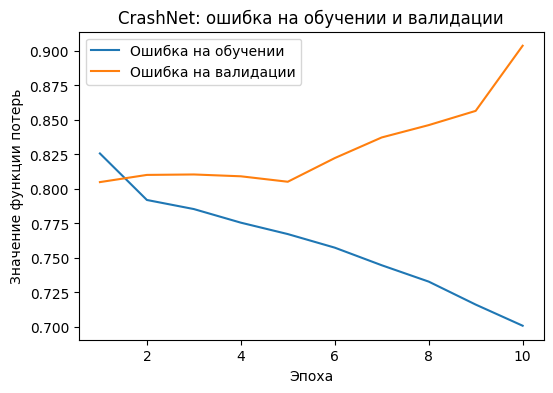

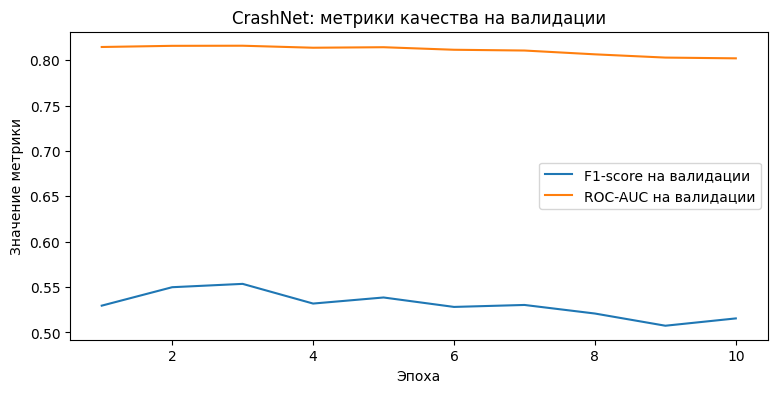

              precision    recall  f1-score   support

   Без травм       0.89      0.85      0.87     15910
  С травмами       0.51      0.60      0.55      4171

    accuracy                           0.80     20081
   macro avg       0.70      0.72      0.71     20081
weighted avg       0.81      0.80      0.80     20081



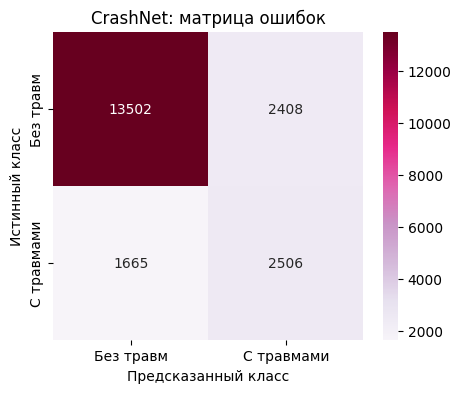

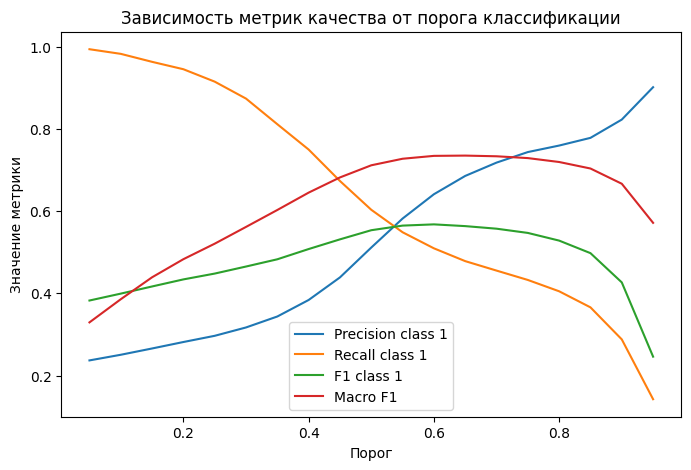

🏃 View run CrashNet at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/5decc536bc6c4265aa43b94b95d7b55c
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


In [ ]:
CrashNet_model, CrashNet_history_data, CrashNet_test_metrics = run_cv_experiment(model_name='CrashNet',
        model = model, train_loader = train_loader, val_loader = val_loader,
        test_loader = test_loader, criterion = criterion, optimizer = optimizer,
        device = device, num_epochs=num_epochs, params = CrashNet_params)

In [ ]:
pd.DataFrame([CrashNet_test_metrics])

,loss,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,roc_auc
0,0.818155,0.797171,0.724732,0.509972,0.600815,0.551679,0.710309,0.814542


In [ ]:
CrashNet_history_data

,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_roc_auc,epoch_time_sec
0,1,0.825721,0.804951,0.755938,0.721000,0.441563,0.661232,0.529519,0.682376,0.814461,3.472449
1,2,0.791999,0.810167,0.790847,0.725959,0.497189,0.614960,0.549839,0.706809,0.815742,3.711580
2,3,0.785405,0.810489,0.797869,0.726056,0.511382,0.603213,0.553514,0.711439,0.815861,3.137743
3,4,0.775545,0.809163,0.751706,0.724873,0.437104,0.678974,0.531831,0.681441,0.813648,4.069438
4,5,0.767270,0.805216,0.771774,0.723564,0.464236,0.641093,0.538516,0.693458,0.814208,3.486810
5,6,0.757426,0.822373,0.748519,0.722331,0.432706,0.677535,0.528126,0.678353,0.811413,2.955189
6,7,0.744665,0.837334,0.745929,0.725474,0.430429,0.690482,0.530289,0.678080,0.810566,3.019200
7,8,0.732808,0.846275,0.737314,0.718887,0.419275,0.687365,0.520847,0.669952,0.806375,2.966708
8,9,0.716152,0.856593,0.713809,0.712279,0.394877,0.709662,0.507414,0.652865,0.802789,3.009237
9,10,0.700822,0.903838,0.733280,0.714749,0.413918,0.683050,0.515470,0.665733,0.801964,3.713402


Модель очевидно переобучается с эпохами, что ж проверим другие

In [ ]:
model1 = CrashNet1(X_train_tensor.shape[1]).to(device)
model1

CrashNet1(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU()
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)

Эпоха 1/10 | ошибка на обучении: 0.8354 | ошибка на валидации: 0.8046 | accuracy: 0.7546 | F1: 0.5319 | ROC-AUC: 0.8156 | время эпохи: 4.5 сек
Эпоха 2/10 | ошибка на обучении: 0.8015 | ошибка на валидации: 0.8010 | accuracy: 0.7458 | F1: 0.5297 | ROC-AUC: 0.8157 | время эпохи: 4.3 сек
Эпоха 3/10 | ошибка на обучении: 0.7955 | ошибка на валидации: 0.8030 | accuracy: 0.7600 | F1: 0.5324 | ROC-AUC: 0.8142 | время эпохи: 4.8 сек
Эпоха 4/10 | ошибка на обучении: 0.7891 | ошибка на валидации: 0.8050 | accuracy: 0.7467 | F1: 0.5297 | ROC-AUC: 0.8167 | время эпохи: 5.1 сек
Эпоха 5/10 | ошибка на обучении: 0.7848 | ошибка на валидации: 0.8039 | accuracy: 0.7616 | F1: 0.5340 | ROC-AUC: 0.8149 | время эпохи: 4.4 сек
Эпоха 6/10 | ошибка на обучении: 0.7819 | ошибка на валидации: 0.8056 | accuracy: 0.7818 | F1: 0.5429 | ROC-AUC: 0.8149 | время эпохи: 5.3 сек
Эпоха 7/10 | ошибка на обучении: 0.7771 | ошибка на валидации: 0.8053 | accuracy: 0.7639 | F1: 0.5358 | ROC-AUC: 0.8161 | время эпохи: 4.6 сек

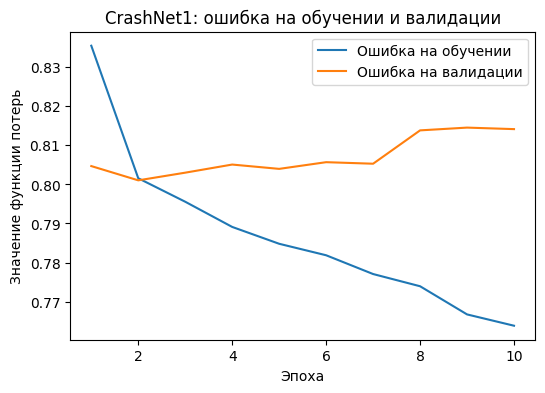

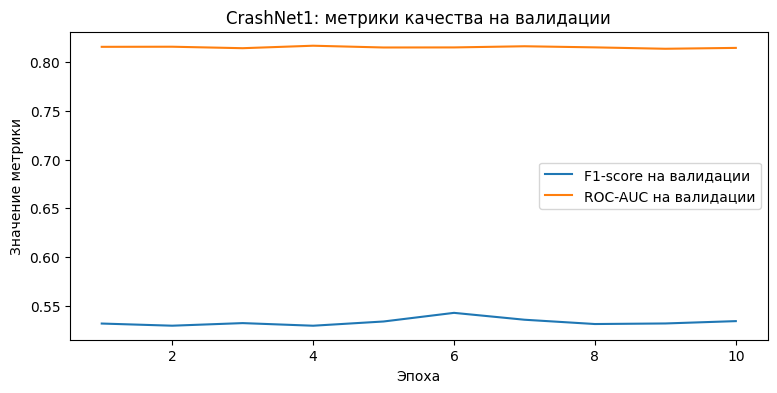

              precision    recall  f1-score   support

   Без травм       0.89      0.82      0.86     15910
  С травмами       0.48      0.63      0.55      4171

    accuracy                           0.78     20081
   macro avg       0.69      0.73      0.70     20081
weighted avg       0.81      0.78      0.79     20081



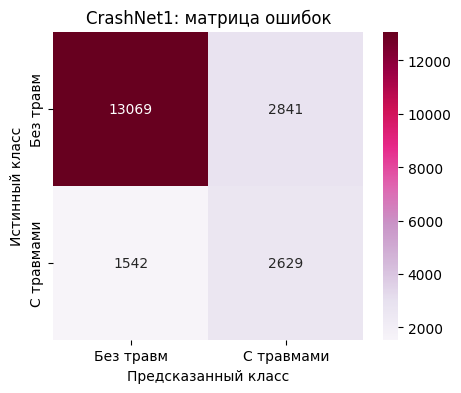

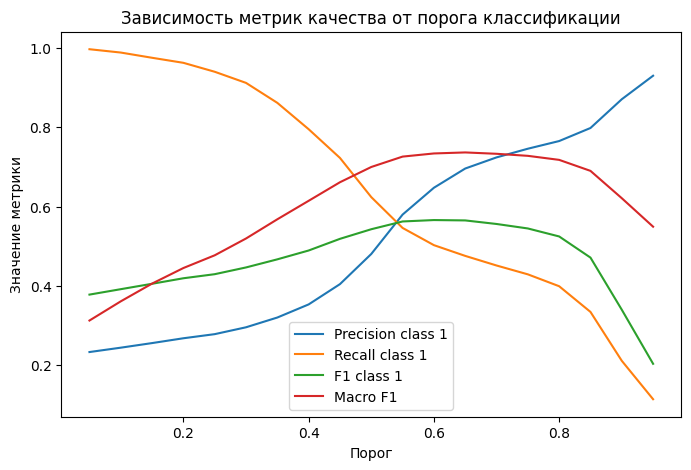

🏃 View run CrashNet1 at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/e674f137e1cf4060919f4ca4a3533a85
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


In [ ]:
CrashNet1_model, CrashNet1_history_data, CrashNet1_test_metrics = run_cv_experiment(model_name='CrashNet1',
        model = model1, train_loader = train_loader, val_loader = val_loader,
        test_loader = test_loader, criterion = criterion, optimizer = optimizer1,
        device = device, num_epochs=num_epochs, params = CrashNet1_params)

In [ ]:
pd.DataFrame([CrashNet1_test_metrics])

,loss,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,roc_auc
0,0.810573,0.781734,0.725869,0.480622,0.630304,0.545379,0.700887,0.814518


In [ ]:
CrashNet1_history_data

,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_roc_auc,epoch_time_sec
0,1,0.835387,0.804650,0.754594,0.723866,0.440459,0.671302,0.531915,0.682810,0.815556,4.509048
1,2,0.801539,0.801009,0.745780,0.724937,0.430132,0.689283,0.529710,0.677760,0.815666,4.300738
2,3,0.795544,0.802967,0.760022,0.722250,0.447180,0.657636,0.532363,0.685480,0.814154,4.837142
3,4,0.789111,0.805040,0.746726,0.724561,0.431131,0.686646,0.529684,0.678192,0.816691,5.072325
4,5,0.784808,0.803937,0.761615,0.723255,0.449525,0.657636,0.534021,0.686931,0.814879,4.400649
5,6,0.781874,0.805646,0.781784,0.723512,0.480517,0.623831,0.542875,0.699780,0.814946,5.294871
6,7,0.777081,0.805254,0.763856,0.724139,0.452771,0.656198,0.535826,0.688737,0.816138,4.583739
7,8,0.773962,0.813768,0.749714,0.725208,0.434783,0.683289,0.531419,0.680338,0.815000,4.387249
8,9,0.766770,0.814476,0.755291,0.723687,0.441302,0.669624,0.532000,0.683167,0.813573,4.851189
9,10,0.763882,0.814090,0.761018,0.723851,0.448827,0.660273,0.534394,0.686825,0.814456,4.332127


In [ ]:
model2 = CrashNet2(X_train_tensor.shape[1]).to(device)
model2

CrashNet2(
  (fc1): Linear(in_features=181, out_features=256, bias=True)
  (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (act1): GELU(approximate='none')
  (drop1): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (ln3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (act2): GELU(approximate='none')
  (drop2): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=64, out_features=32, bias=True)
  (ln4): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (act3): GELU(approximate='none')
  (drop3): Dropout(p=0.2, inplace=False)
  (fc5): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

Эпоха 1/10 | ошибка на обучении: 0.8413 | ошибка на валидации: 0.8130 | accuracy: 0.7205 | F1: 0.5110 | ROC-AUC: 0.8103 | время эпохи: 4.5 сек
Эпоха 2/10 | ошибка на обучении: 0.8134 | ошибка на валидации: 0.8033 | accuracy: 0.7502 | F1: 0.5291 | ROC-AUC: 0.8154 | время эпохи: 5.1 сек
Эпоха 3/10 | ошибка на обучении: 0.8053 | ошибка на валидации: 0.8040 | accuracy: 0.7777 | F1: 0.5377 | ROC-AUC: 0.8144 | время эпохи: 4.4 сек
Эпоха 4/10 | ошибка на обучении: 0.8006 | ошибка на валидации: 0.8011 | accuracy: 0.7840 | F1: 0.5421 | ROC-AUC: 0.8163 | время эпохи: 5.7 сек
Эпоха 5/10 | ошибка на обучении: 0.7997 | ошибка на валидации: 0.8014 | accuracy: 0.8022 | F1: 0.5510 | ROC-AUC: 0.8151 | время эпохи: 5.3 сек
Эпоха 6/10 | ошибка на обучении: 0.7958 | ошибка на валидации: 0.8067 | accuracy: 0.7499 | F1: 0.5266 | ROC-AUC: 0.8133 | время эпохи: 5.4 сек
Эпоха 7/10 | ошибка на обучении: 0.7956 | ошибка на валидации: 0.8024 | accuracy: 0.7553 | F1: 0.5335 | ROC-AUC: 0.8164 | время эпохи: 5.1 сек

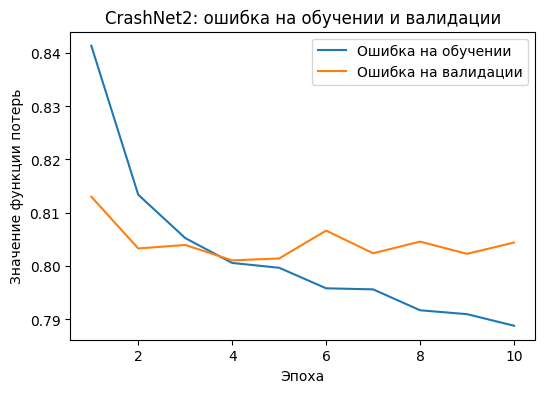

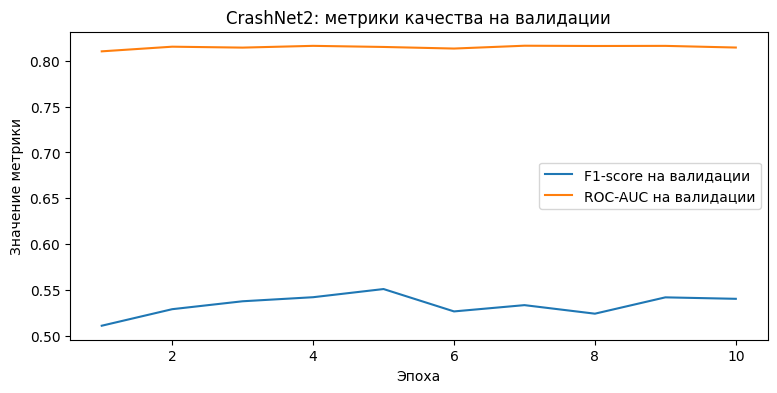

              precision    recall  f1-score   support

   Без травм       0.89      0.86      0.87     15910
  С травмами       0.52      0.59      0.55      4171

    accuracy                           0.80     20081
   macro avg       0.71      0.72      0.71     20081
weighted avg       0.81      0.80      0.81     20081



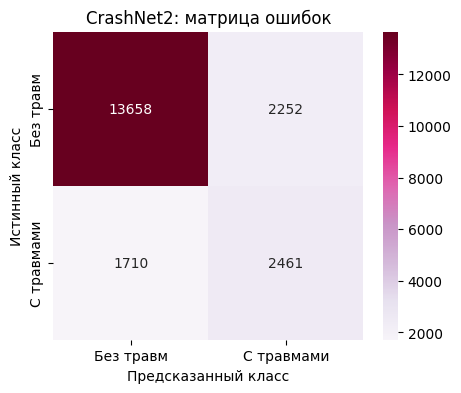

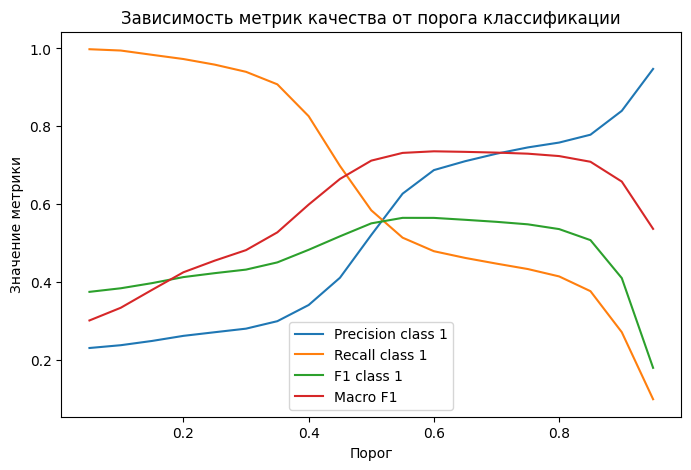

🏃 View run CrashNet2 at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/7a90657e186e404195a2cd6c848020fc
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


In [ ]:
CrashNet2_model, CrashNet2_history_data, CrashNet2_test_metrics = run_cv_experiment(model_name='CrashNet2',
        model = model2, train_loader = train_loader, val_loader = val_loader,
        test_loader = test_loader, criterion = criterion, optimizer = optimizer2,
        device = device, num_epochs=num_epochs, params = CrashNet2_params)

In [ ]:
pd.DataFrame([CrashNet2_test_metrics])

,loss,accuracy,balanced_accuracy,precision,recall,f1,macro_f1,roc_auc
0,0.808957,0.802699,0.72424,0.522173,0.590026,0.55403,0.71368,0.814867


In [ ]:
CrashNet2_history_data

,epoch,train_loss,val_loss,val_accuracy,val_balanced_accuracy,val_precision,val_recall,val_f1,val_macro_f1,val_roc_auc,epoch_time_sec
0,1,0.841349,0.813023,0.720482,0.714102,0.401341,0.703189,0.511020,0.657665,0.810283,4.475050
1,2,0.813390,0.803304,0.750162,0.722661,0.434742,0.675617,0.529053,0.679518,0.815352,5.108467
2,3,0.805252,0.803965,0.777700,0.720404,0.473291,0.622393,0.537697,0.695682,0.814354,4.448833
3,4,0.800584,0.801070,0.783975,0.721888,0.484254,0.615680,0.542115,0.700379,0.816270,5.744457
4,5,0.799682,0.801429,0.802151,0.721860,0.521163,0.584512,0.551023,0.712071,0.815062,5.278435
5,6,0.795826,0.806657,0.749863,0.720350,0.433851,0.669863,0.526623,0.678323,0.813332,5.382145
6,7,0.795628,0.802401,0.755341,0.725133,0.441667,0.673460,0.533473,0.683833,0.816412,5.099565
7,8,0.791704,0.804590,0.738061,0.722012,0.420892,0.694558,0.524154,0.671724,0.816118,4.688404
8,9,0.790974,0.802297,0.775509,0.725301,0.470287,0.639415,0.541963,0.696641,0.816248,5.026014
9,10,0.788806,0.804416,0.778895,0.722397,0.475496,0.625749,0.540373,0.697404,0.814439,5.554199


В целом CrashNet2 получше себя ведет чем другие модели, не так заметно переобучается. Да и macro_f1 получше, чем у двух других моделей

In [ ]:
for epoch in range(num_epochs):
    print(f"'эпоха {epoch + 1}/{num_epochs}")
    train(model, device, train_loader, optimizer, criterion)
    y_true, y_probs = test(model, device, test_loader, criterion)
    print()

'эпоха 1/10
Train loss: 0.8243385823643578, Train accuracy: 0.7502474369269267
Test loss: 0.8079020623807553, Test accuracy: 0.7948085901027078

'эпоха 2/10
Train loss: 0.7931948668347907, Train accuracy: 0.7654204560309249
Test loss: 0.8120640560432717, Test accuracy: 0.7811391223155929

'эпоха 3/10
Train loss: 0.7846496018418834, Train accuracy: 0.7657379222767933
Test loss: 0.8126557381064804, Test accuracy: 0.7423342670401494

'эпоха 4/10
Train loss: 0.7776434162636077, Train accuracy: 0.7635903564959197
Test loss: 0.8077352113193936, Test accuracy: 0.7446125116713352

'эпоха 5/10
Train loss: 0.7701023835555466, Train accuracy: 0.76568189882164
Test loss: 0.8120782176653544, Test accuracy: 0.7273202614379085

'эпоха 6/10
Train loss: 0.7596889765564183, Train accuracy: 0.7652337111804142
Test loss: 0.8358617380813316, Test accuracy: 0.778375350140056

'эпоха 7/10
Train loss: 0.7500947504737782, Train accuracy: 0.7664102037386319
Test loss: 0.8281601888162119, Test accuracy: 0.703454

ЖЕСТЬ ОНО РАБОТАЕТ УРААААА

### Важность признаков


In [344]:
best_model = CrashNet2(X_train_tensor.shape[1])
state_dict = torch.load("CrashNet2.pt", map_location=device, weights_only=True)
best_model.load_state_dict(state_dict)
best_model.to(device)
best_model.eval()
def score_func(X_proc, y_true):
    X_t = torch.tensor(X_proc, dtype=torch.float32).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(best_model(X_t)).cpu().numpy().reshape(-1)
    return roc_auc_score(y_true, probs)
importances_list = []

In [345]:
baseline_score = score_func(preprocessor.transform(X_val), y_val.values)
print(f"Baseline ROC-AUC: {baseline_score:.4f}")
for i in range(X_val.shape[1]):
    feature_importances = []
    X_val_perm = X_val.copy()
    X_val_perm.iloc[:, i] = np.random.permutation(X_val_perm.iloc[:, i].values)
    X_val_perm_proc = preprocessor.transform(X_val_perm)
    perm_score = score_func(X_val_perm_proc, y_val.values)
    feature_importances.append(baseline_score - perm_score)
    importances_list.append(np.mean(feature_importances))
importance_df = pd.DataFrame({"feature": X_val.columns,
                              "importance": importances_list}).sort_values("importance", ascending=False)

Baseline ROC-AUC: 0.8151


In [348]:
importance_df.head(10)

,feature,importance
6,mannerofcrash,0.046751
28,has_unknown_age,0.031783
16,has_occupant,0.029159
11,num_people,0.014094
12,num_drivers,0.011978
15,has_pedestrian,0.011249
18,has_motorcycle,0.008899
14,num_pedestrians,0.006996
8,roadcontour,0.004892
2,community_council_neighborhood,0.003936


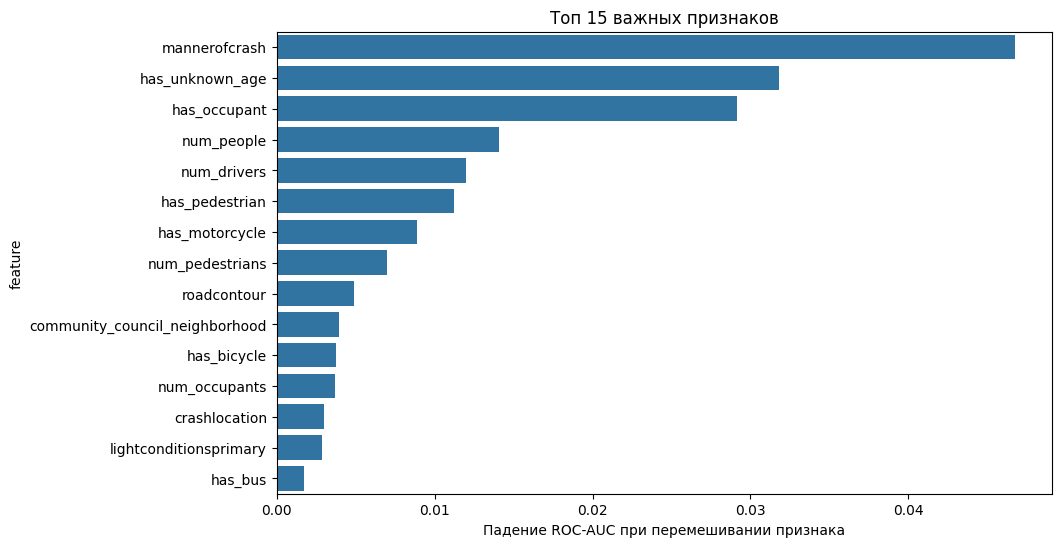

In [350]:
plt.figure(figsize = (10, 6))
sns.barplot(data = importance_df.head(15), x="importance", y="feature")
plt.title(f"Топ 15 важных признаков")
plt.xlabel("Падение ROC-AUC при перемешивании признака")
importance_plot_path = "artifacts/plots/permutation_importance.png"
plt.savefig(importance_plot_path)
plt.show()

##Вторая модель, Entity Embeddings

В этом варианте архитектуры возьмем label encoding для категориальных признаков вместо One-hot.

In [ ]:
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(X, y, test_size = 0.2,
                                                                    random_state = 42, stratify = y)

In [ ]:
encoders = {}
cat_card = []
for col in cat_cols_x:
    encoder = LabelEncoder()
    X_train_emb[col] = encoder.fit_transform(X_train_emb[col].astype(str))
    X_test_emb[col] = encoder.transform(X_test_emb[col].astype(str))
    encoders[col] = encoder
    cat_card.append(len(encoder.classes_))
encoders

{'community_council_neighborhood': LabelEncoder(),
 'crashlocation': LabelEncoder(),
 'dayofweek': LabelEncoder(),
 'lightconditionsprimary': LabelEncoder(),
 'mannerofcrash': LabelEncoder(),
 'roadconditionsprimary': LabelEncoder(),
 'roadcontour': LabelEncoder(),
 'roadsurface': LabelEncoder(),
 'weather': LabelEncoder()}

In [ ]:
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_emb[num_cols_x])
X_test_num_scaled = scaler.transform(X_test_emb[num_cols_x])
X_train_num = X_train_num_scaled.astype(np.float32)
X_test_num = X_test_num_scaled.astype(np.float32)
X_train_cat = X_train_emb[cat_cols_x].values.astype(np.int64)
X_test_cat = X_test_emb[cat_cols_x].values.astype(np.int64)
y_train_emb_np = y_train_emb.values.astype(np.float32).reshape(-1, 1)
y_test_emb_np = y_test_emb.values.astype(np.float32).reshape(-1, 1)
print(f"X_train_num: {X_train_num.shape}")
print(f"X_train_cat: {X_train_cat.shape}")
print(f"y_train: {y_train_emb_np.shape}")

X_train_num: (107098, 24)
X_train_cat: (107098, 9)
y_train: (107098, 1)


Окей, преобразовали, теперь модель. Но сначала посмотрим вспомним кардинальность категориальных признаков. Максимальная кардинальность - 72, минимальная - 6. Есть такая штука как эвристики для размеров векторов эмбеддингов. Мне нравки вот эта min(600, 1.6 * N^0.56), она от FastAi. Что ж, буду использовать её

In [ ]:
cat_card

[72, 14, 8, 15, 10, 12, 6, 9, 13]

In [ ]:
class EntityEmbeddingsNet(nn.Module):
    def __init__(self, num_continuous, cat_cardinalities, embedding_dims=None):
        super().__init__()

        self.num_continuous = num_continuous
        self.cat_cardinalities = cat_cardinalities

        if embedding_dims is None:
            self.embedding_dims = [int(1.6 * (card ** 0.56)) for card in cat_cardinalities]
        else:
            self.embedding_dims = embedding_dims

        self.embeddings = nn.ModuleList([nn.Embedding(num_embeddings=card, embedding_dim=dim)
            for card, dim in zip(cat_cardinalities, self.embedding_dims)])

        self.emb_dropout = nn.Dropout(0.1)

        total_emb_size = sum(self.embedding_dims)
        input_size = total_emb_size + num_continuous

        self.mlp = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(64, 1)
        )

    def forward(self, x_num, x_cat):
        emb_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            emb = emb_layer(x_cat[:, i])
            emb_outputs.append(emb)

        emb_concat = torch.cat(emb_outputs, dim=1)
        emb_concat = self.emb_dropout(emb_concat)

        x = torch.cat([x_num, emb_concat], dim=1)

        return self.mlp(x)

In [ ]:
from torch.utils.data import Dataset

Кастомный лоадер, тк два вида признаков на вход подаются



In [ ]:
class CustomDataset(Dataset):
    def __init__(self, x_num, x_cat, y):
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y[idx]

train_dataset = CustomDataset(X_train_num, X_train_cat, y_train_emb_np)
test_dataset = CustomDataset(X_test_num, X_test_cat, y_test_emb_np)

train_loader_emb = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader_emb = DataLoader(test_dataset, batch_size=1024, shuffle=False)

### Функция обучения

In [ ]:
def train_emb(model, device, train_loader, optimizer, criterion):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for x_num, x_cat, target in train_loader:
        x_num = x_num.to(device)
        x_cat = x_cat.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(x_num, x_cat)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        probs = torch.sigmoid(output)
        pred = (probs >= 0.5).float()
        correct += (pred == target).sum().item()
        total += target.size(0)

    avg_loss = train_loss / len(train_loader)
    accuracy = correct / total
    print(f"Train loss: {avg_loss:.4f}, Train accuracy: {accuracy:.4f}")
    return avg_loss, accuracy

In [ ]:
def test_emb(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for x_num, x_cat, target in test_loader:
            x_num = x_num.to(device)
            x_cat = x_cat.to(device)
            target = target.to(device)

            output = model(x_num, x_cat)
            loss = criterion(output, target)

            test_loss += loss.item()
            probs = torch.sigmoid(output)
            pred = (probs >= 0.5).float()
            correct += (pred == target).sum().item()
            total += target.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(target.cpu().numpy())
    all_preds = (np.array(all_probs)>=0.5).astype(int)
    avg_loss = test_loss / len(test_loader)
    accuracy = correct / total
    print(f"Test loss: {avg_loss:.4f}, Test accuracy: {accuracy:.4f}")
    metrics = {
        'loss': avg_loss,
        'accuracy': accuracy_score(all_labels, all_preds),
        'balanced_accuracy': balanced_accuracy_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0),
        'f1': f1_score(all_labels, all_preds, zero_division=0),
        'macro_f1': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'roc_auc': roc_auc_score(all_labels, all_probs)
    }
    return metrics

### Обучаем

In [ ]:
emb_model = EntityEmbeddingsNet(num_continuous=len(num_cols_x),cat_cardinalities=cat_card).to(device)
emb_model

EntityEmbeddingsNet(
  (embeddings): ModuleList(
    (0): Embedding(72, 17)
    (1): Embedding(14, 7)
    (2): Embedding(8, 5)
    (3): Embedding(15, 7)
    (4): Embedding(10, 5)
    (5): Embedding(12, 6)
    (6): Embedding(6, 4)
    (7): Embedding(9, 5)
    (8): Embedding(13, 6)
  )
  (emb_dropout): Dropout(p=0.1, inplace=False)
  (mlp): Sequential(
    (0): Linear(in_features=86, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_feature

In [ ]:
pos_weight_emb = torch.tensor(
    [(y_train_emb == 0).sum() / (y_train_emb == 1).sum()],
    dtype=torch.float32
).to(device)

In [ ]:
criterion_emb = nn.BCEWithLogitsLoss(pos_weight=pos_weight_emb)

In [ ]:
optimizer_emb = torch.optim.Adam(emb_model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
num_epochs = 15
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_macro_f1 = 0

for epoch in range(num_epochs):
    print(f"\n'Эпоха {epoch + 1}/{num_epochs}")
    train_loss, train_acc = train_emb(emb_model, device, train_loader_emb, optimizer_emb, criterion_emb)
    metrics = test_emb(emb_model, device, test_loader_emb, criterion_emb)
    train_losses.append(train_loss)
    test_losses.append(metrics['loss'])
    train_accs.append(train_acc)
    test_accs.append(metrics['accuracy'])
    if metrics['macro_f1'] > best_macro_f1:
              best_val_macro_f1 = metrics['macro_f1']
              best_epoch = epoch + 1
              best_metrics = metrics.copy()
              best_emb_model_state_dict = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print()


'Эпоха 1/15
Train loss: 0.7648, Train accuracy: 0.7602
Test loss: 0.8276, Test accuracy: 0.7463


'Эпоха 2/15
Train loss: 0.7617, Train accuracy: 0.7604
Test loss: 0.8226, Test accuracy: 0.7429


'Эпоха 3/15
Train loss: 0.7604, Train accuracy: 0.7593
Test loss: 0.8226, Test accuracy: 0.7635


'Эпоха 4/15
Train loss: 0.7612, Train accuracy: 0.7589
Test loss: 0.8305, Test accuracy: 0.7656


'Эпоха 5/15
Train loss: 0.7596, Train accuracy: 0.7640
Test loss: 0.8326, Test accuracy: 0.7712


'Эпоха 6/15
Train loss: 0.7582, Train accuracy: 0.7599
Test loss: 0.8301, Test accuracy: 0.7706


'Эпоха 7/15
Train loss: 0.7579, Train accuracy: 0.7588
Test loss: 0.8297, Test accuracy: 0.7253


'Эпоха 8/15
Train loss: 0.7539, Train accuracy: 0.7587
Test loss: 0.8260, Test accuracy: 0.7419


'Эпоха 9/15
Train loss: 0.7571, Train accuracy: 0.7599
Test loss: 0.8276, Test accuracy: 0.7571


'Эпоха 10/15
Train loss: 0.7547, Train accuracy: 0.7594
Test loss: 0.8328, Test accuracy: 0.7400


'Эпоха 11/15
Train

In [336]:
best_metrics

{'loss': 0.8381951451301575,
 'accuracy': 0.7518954248366013,
 'balanced_accuracy': np.float64(0.7200980759229294),
 'precision': 0.43624793777987275,
 'recall': 0.6657076065455854,
 'f1': 0.5270876343703281,
 'macro_f1': 0.6794615955817416,
 'roc_auc': np.float64(0.808966829269831)}

###Метрики и трешхолд

In [ ]:
_, _, y_true_emb, y_probs_emb = test_emb(emb_model, device, test_loader_emb, criterion_emb)
threshold_results_emb = []
thresholds = np.arange(0.05, 0.96, 0.05)
for thres in thresholds:
    y_pred_t = (y_probs_emb >= thres).astype(int)
    threshold_results_emb.append({
        'threshold': thres,
        'accuracy': accuracy_score(y_true_emb, y_pred_t),
        'precision': precision_score(y_true_emb, y_pred_t),
        'recall': recall_score(y_true_emb, y_pred_t),
        'macro_f1': f1_score(y_true_emb, y_pred_t, average = 'macro'),
        'f1': f1_score(y_true_emb, y_pred_t)
    })

thresholds_df_emb = pd.DataFrame(threshold_results_emb)
thresholds_df_emb

Test loss: 0.8068, Test accuracy: 0.7675


,threshold,accuracy,precision,recall,macro_f1,f1
0,0.05,0.318207,0.233050,0.996404,0.311907,0.377748
1,0.10,0.351335,0.241426,0.991189,0.348961,0.388278
2,0.15,0.395145,0.253111,0.980219,0.395057,0.402332
3,0.20,0.434958,0.264590,0.966912,0.434330,0.415485
4,0.25,0.470551,0.275686,0.951987,0.467547,0.427556
5,0.30,0.511746,0.289084,0.925733,0.503715,0.440584
6,0.35,0.564556,0.308696,0.884733,0.546966,0.457696
7,0.40,0.624426,0.335625,0.825211,0.592067,0.477176
8,0.45,0.694118,0.380446,0.752203,0.641964,0.505315
9,0.50,0.767544,0.457958,0.649344,0.690957,0.537111


In [ ]:
best_threshold_emb = thresholds_df_emb.loc[thresholds_df_emb['macro_f1'].idxmax(), 'threshold']
best_threshold_emb

np.float64(0.6500000000000001)

In [ ]:
y_pred_best_emb = (y_probs_emb >= best_threshold_emb).astype(int)
print(f"ROC-AUC: {roc_auc_score(y_true_emb, y_probs_emb):.4f}")

ROC-AUC: 0.8145


### Логгируем

In [342]:
with mlflow.start_run(run_name="Entity_Embeddings_Net"):
    mlflow.log_param("model_name", "EntityEmbeddingsNet")
    mlflow.log_param("num_continuous_features", len(num_cols))
    mlflow.log_param("num_categorical_features", len(cat_cols))
    mlflow.log_param("batch_size_train", 256)
    mlflow.log_param("batch_size_test", 1024)
    mlflow.log_param("epochs", 15)
    mlflow.log_param("learning_rate", 0.001)
    mlflow.log_param("loss_function", "BCEWithLogitsLoss")
    mlflow.log_param("pos_weight", pos_weight_emb.item())
    mlflow.log_param("best_threshold", best_threshold_emb)
    for key, value in metrics.items():
        mlflow.log_metric(key, float(value))
    mlflow.log_metric('best_epoch', best_epoch)
    model__path = f'artifacts/models/EntityEmbeddingsNet.pt'
    torch.save(best_emb_model_state_dict, model__path)
    mlflow.log_artifact(model__path)
    np.save("artifacts/data/EntityEmbeddingNet/X_train_num.npy", X_train_num)
    np.save("artifacts/data/EntityEmbeddingNet/X_train_cat.npy", X_train_cat)
    np.save("artifacts/data/EntityEmbeddingNet/y_train.npy", y_train_emb_np)
    np.save("artifacts/data/EntityEmbeddingNet/X_test_num.npy", X_test_num)
    np.save("artifacts/data/EntityEmbeddingNet/X_test_cat.npy", X_test_cat)
    np.save("artifacts/data/EntityEmbeddingNet/y_test.npy", y_test_emb_np)
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/X_train_num.npy")
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/X_train_cat.npy")
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/y_train.npy")
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/X_test_num.npy")
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/X_test_cat.npy")
    mlflow.log_artifact("artifacts/data/EntityEmbeddingNet/y_test.npy")

🏃 View run Entity_Embeddings_Net at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0/runs/5c674db665d64e18a888d6b1b7911809
🧪 View experiment at: https://dagshub.com/RenataMal/GP5.mlflow/#/experiments/0


##Сравнение с классической моделью

Сравним, как справляется с задачей на наших данных модель Random Forest. Таким образом мы сможем оценить полезность и уместность примения полносвязной нейронной сети для нашей задачи.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
RF = RandomForestClassifier(n_estimators = 100, criterion = 'entropy', max_depth = 15, class_weight = 'balanced', random_state=42, n_jobs=-1)
RF.fit(X_train_ready, y_train)
RF_pred = RF.predict(X_test_ready)
RF_prob = RF.predict_proba(X_test_ready)[:, 1]

In [ ]:
print(f'accuracy: {accuracy_score(y_test, RF_pred)}')
print(f'precision: {precision_score(y_test, RF_pred)}')
print(f'recall: {recall_score(y_test, RF_pred)}')
print(f'f1-score: {f1_score(y_test, RF_pred)}')
print(f'roc-auc: {roc_auc_score(y_test, RF_prob)}')

Теперь займемся подбором гиперпараметров RF, сделаю через RandomizedSearchCV, а не полный перебор. Общее число комбинаций - 216, остановимся на 40 комбинациях (иначе долго будет, наверное).

In [ ]:
hyperparams = {
    'n_estimators': [70, 100, 150, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
RF_base = RandomForestClassifier(class_weight = 'balanced', random_state = 42, n_jobs = -1)
RF_search = RandomizedSearchCV(estimator = RF_base, param_distributions = hyperparams, n_iter = 40,
    cv = 3, scoring = 'f1', random_state = 42, n_jobs = -1, verbose = 1)
RF_search.fit(X_train_ready, y_train)

In [ ]:
print(RF_search.best_params_)

In [ ]:
best_rf_model = RF_search.best_estimator_
RF_search_pred = best_rf_model.predict(X_test_ready)
RF_search_prob = best_rf_model.predict_proba(X_test_ready)[:, 1]

In [ ]:
print(f'accuracy: {accuracy_score(y_test, RF_search_pred)}')
print(f'precision: {precision_score(y_test, RF_search_pred)}')
print(f'recall: {recall_score(y_test, RF_search_pred)}')
print(f'f1-score: {f1_score(y_test, RF_search_pred)}')
print(f'roc-auc: {roc_auc_score(y_test, RF_search_prob)}')

Ура, спустя 42 минуты получили лучший вариант гиперпараметров. В целом, совсем чут-чут лучше бэйслайна. Осталось залоггировать.

In [ ]:
with mlflow.start_run(run_name="RF_baseline"):
    mlflow.log_param("n_estimators", 150)
    mlflow.log_param("max_depth", 20)
    mlflow.log_param("min_samples_split", 10)
    mlflow.log_param("min_samples_leaf", 1)
    mlflow.log_param("criterion", "entropy")
    mlflow.log_param("search_method", "GridSearchCV")
    mlflow.log_param("cv_folds", 3)
    mlflow.log_param("scoring_metric", "f1")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_metric("accuracy", accuracy_score(y_test, RF_search_pred))
    mlflow.log_metric("precision_class_1", precision_score(y_test, RF_search_pred))
    mlflow.log_metric("recall_class_1", recall_score(y_test, RF_search_pred))
    mlflow.log_metric("f1_class_1", f1_score(y_test, RF_search_pred))
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, RF_search_prob))
    mlflow.sklearn.log_model(best_rf_model, "best_RF_model")